# <center> $\Large{\text{Univariate Analysis}}$ <br> Laminar Level (1.96 Sound) </center>

In [1]:
%autoreload 2

In [2]:
import sys
import itertools
from glob import glob
from tqdm import tqdm
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

import bvbabel
import matlab.engine

import scipy.io as sio
from scipy.stats import ttest_rel, ttest_1samp, friedmanchisquare

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import fdrcorrection
import scikit_posthocs as sp

sys.path.insert(0, '/mnt/hdd2/associative_learning/notebooks/toolbox/')
from fmri_toolbox import FMRIToolbox

# matlab and seaborn config
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
sns.set(style="whitegrid")
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
def add_significance(ax, x1, x2, y, h, text):
    if text=='ns': return
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='black')
    ax.text((x1 + x2) * .5, y + h, text, ha='center', va='bottom', color='black', fontsize=20)
plt.rcParams['text.usetex'] = True

- Layer 1 (D) Deep
- Layer 2 (M) Middle
- Layer 3 (S) Surface

### Load data

In [3]:
data_dir = f'/mnt/hdd2/associative_learning/analysis/estimates/single_trial_gm_mask'
mask_dir = '/mnt/hdd2/associative_learning/masks/drawn_regions/'
tbx = FMRIToolbox(data_dir, mask_dir=mask_dir)
subjects = ['S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S15', 'S17']
regions = ['PP','HG',  'PT', 'aSTG', 'pSTG', 'pMTG', 'parsOrbitalis', 'parsTriangularis', 'TPOj']
hemispheres = ['LH', 'RH']

# load dataset
dataset = tbx.load_dataset(subjects, hemispheres, regions, extract_layers=True)

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

### Plot voxel counts

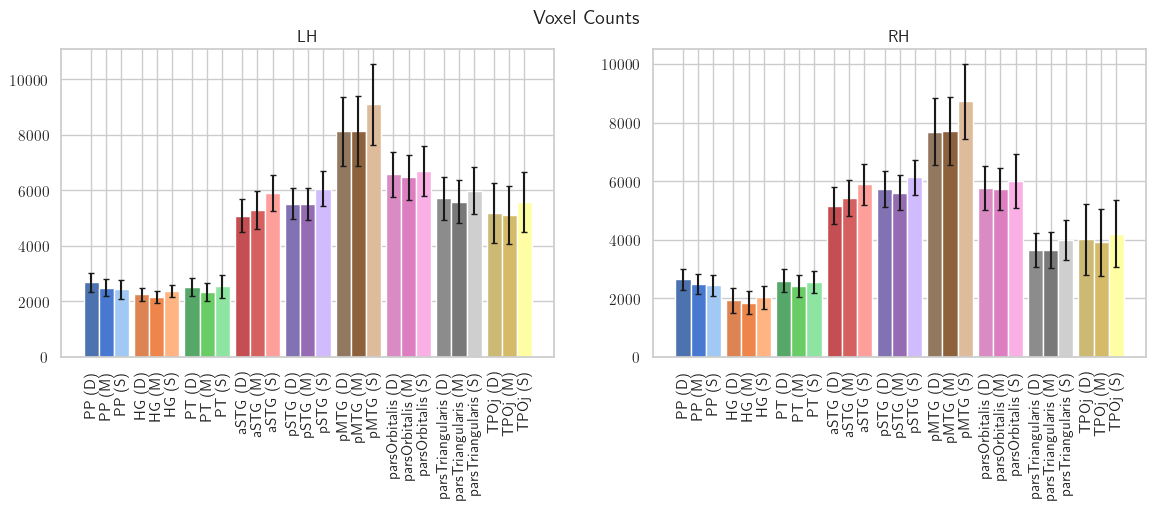

In [4]:
fig = plt.figure(figsize=(14,4))
palette = sns.color_palette()
palette1 = sns.color_palette("muted")
palette2 = sns.color_palette("pastel")

regions_layers_list = np.array([[region + ' (D)', region + ' (M)', region + ' (S)'] for region in regions]).ravel()

ax = plt.subplot(1,2,1)
voxel_counts_lh_l1 = {region:np.mean([dataset[subject]['LH'][region]['betas']['L1'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l1_se = {region:np.std([dataset[subject]['LH'][region]['betas']['L1'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l1_ci = [1.96 * (std_dev / np.sqrt(len(subjects))) for std_dev in voxel_counts_lh_l1_se.values()]
voxel_counts_lh_l2 = {region:np.mean([dataset[subject]['LH'][region]['betas']['L2'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l2_se = {region:np.std([dataset[subject]['LH'][region]['betas']['L2'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l2_ci = [1.96 * (std_dev / np.sqrt(len(subjects))) for std_dev in voxel_counts_lh_l2_se.values()]
voxel_counts_lh_l3 = {region:np.mean([dataset[subject]['LH'][region]['betas']['L3'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l3_se = {region:np.std([dataset[subject]['LH'][region]['betas']['L3'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l3_ci = [1.96 * (std_dev / np.sqrt(len(subjects))) for std_dev in voxel_counts_lh_l3_se.values()]

x_positions1 = np.arange(len(voxel_counts_lh_l1))
ax.bar(x=x_positions1, height=voxel_counts_lh_l1.values(), capsize=2, width=0.3, color=palette, yerr=voxel_counts_lh_l1_ci)
x_positions2 = x_positions1 + 0.3
ax.bar(x=x_positions2, height=voxel_counts_lh_l2.values(), capsize=2, width=0.3, color=palette1, yerr=voxel_counts_lh_l2_ci)
x_positions3 = x_positions1 + 0.6
ax.bar(x=x_positions3, height=voxel_counts_lh_l3.values(), capsize=2, width=0.3, color=palette2, yerr=voxel_counts_lh_l3_ci)
ax.set_xticks(np.sort(np.concatenate([x_positions1, x_positions2, x_positions3])), regions_layers_list)
plt.xticks(rotation=90)
ax.set_title('LH')

##############

ax = plt.subplot(1,2,2)

voxel_counts_lh_l1 = {region:np.mean([dataset[subject]['RH'][region]['betas']['L1'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l1_se = {region:np.std([dataset[subject]['RH'][region]['betas']['L1'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l1_ci = [1.96 * (std_dev / np.sqrt(len(subjects))) for std_dev in voxel_counts_lh_l1_se.values()]
voxel_counts_lh_l2 = {region:np.mean([dataset[subject]['RH'][region]['betas']['L2'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l2_se = {region:np.std([dataset[subject]['RH'][region]['betas']['L2'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l2_ci = [1.96 * (std_dev / np.sqrt(len(subjects))) for std_dev in voxel_counts_lh_l2_se.values()]
voxel_counts_lh_l3 = {region:np.mean([dataset[subject]['RH'][region]['betas']['L3'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l3_se = {region:np.std([dataset[subject]['RH'][region]['betas']['L3'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l3_ci = [1.96 * (std_dev / np.sqrt(len(subjects))) for std_dev in voxel_counts_lh_l3_se.values()]

x_positions1 = np.arange(len(voxel_counts_lh_l1))
ax.bar(x=x_positions1, height=voxel_counts_lh_l1.values(), capsize=2, width=0.3, color=palette, yerr=voxel_counts_lh_l1_ci)
ax.bar(x=x_positions2, height=voxel_counts_lh_l2.values(), capsize=2, width=0.3, color=palette1, yerr=voxel_counts_lh_l2_ci)
ax.bar(x=x_positions3, height=voxel_counts_lh_l3.values(), capsize=2, width=0.3, color=palette2, yerr=voxel_counts_lh_l3_ci)
ax.set_xticks(np.sort(np.concatenate([x_positions1, x_positions2, x_positions3])), regions_layers_list)
plt.xticks(rotation=90)
ax.set_title('RH')

plt.suptitle('Voxel Counts')
plt.show()

### Perform T-Tests

In [5]:
tbx.utils.calculate_tstats(dataset, trials='sound')

calculating t-stats in-place.


  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

...

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

### Check voxels count using one threshold

In [6]:
t_threshold = 1.96
tbx.utils.select_voxels(dataset, selection={'method': 'tstat', 'strategy': 't_val', 'threshold':t_threshold, 'drop_negative':True})

selecting voxels in-place!


  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

...

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

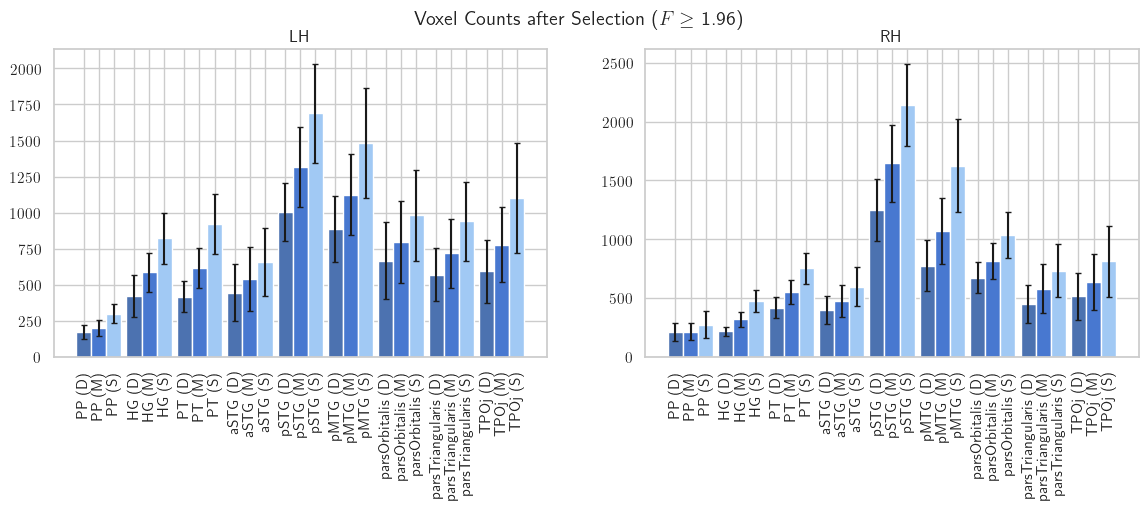

In [7]:
fig = plt.figure(figsize=(14,4))
palette = sns.color_palette()
palette1 = sns.color_palette("muted")
palette2 = sns.color_palette("pastel")

regions_layers_list = np.array([[region + ' (D)', region + ' (M)', region + ' (S)'] for region in regions]).ravel()

ax = plt.subplot(1,2,1)
voxel_counts_lh_l1 = {region:np.nanmean([dataset[subject]['LH'][region]['betas_selected']['L1'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l1_min = {region:np.nanmin([dataset[subject]['LH'][region]['betas_selected']['L1'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l1_se = {region:np.std([dataset[subject]['LH'][region]['betas_selected']['L1'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l1_ci = [1.96 * (std_dev / np.sqrt(len(subjects))) for std_dev in voxel_counts_lh_l1_se.values()]
voxel_counts_lh_l2 = {region:np.nanmean([dataset[subject]['LH'][region]['betas_selected']['L2'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l2_min = {region:np.nanmin([dataset[subject]['LH'][region]['betas_selected']['L2'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l2_se = {region:np.std([dataset[subject]['LH'][region]['betas_selected']['L2'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l2_ci = [1.96 * (std_dev / np.sqrt(len(subjects))) for std_dev in voxel_counts_lh_l2_se.values()]
voxel_counts_lh_l3 = {region:np.nanmean([dataset[subject]['LH'][region]['betas_selected']['L3'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l3_min = {region:np.nanmin([dataset[subject]['LH'][region]['betas_selected']['L3'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l3_se = {region:np.std([dataset[subject]['LH'][region]['betas_selected']['L3'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l3_ci = [1.96 * (std_dev / np.sqrt(len(subjects))) for std_dev in voxel_counts_lh_l3_se.values()]

x_positions1 = np.arange(len(voxel_counts_lh_l1))
ax.bar(x=x_positions1, height=voxel_counts_lh_l1.values(), capsize=2, width=0.3, color=palette[0], yerr=voxel_counts_lh_l1_ci)
x_positions2 = x_positions1 + 0.3
ax.bar(x=x_positions2, height=voxel_counts_lh_l2.values(), capsize=2, width=0.3, color=palette1[0], yerr=voxel_counts_lh_l2_ci)
x_positions3 = x_positions1 + 0.6
ax.bar(x=x_positions3, height=voxel_counts_lh_l3.values(), capsize=2, width=0.3, color=palette2[0], yerr=voxel_counts_lh_l3_ci)
ax.set_xticks(np.sort(np.concatenate([x_positions1, x_positions2, x_positions3])), regions_layers_list)
plt.xticks(rotation=90)
ax.set_title('LH')

##############

regions_layers_list = np.array([[region + ' (D)', region + ' (M)', region + ' (S)'] for region in regions]).ravel()

ax = plt.subplot(1,2,2)

voxel_counts_rh_l1 = {region:np.nanmean([dataset[subject]['RH'][region]['betas_selected']['L1'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_rh_l1_min = {region:np.nanmin([dataset[subject]['RH'][region]['betas_selected']['L1'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_rh_l1_se = {region:np.std([dataset[subject]['RH'][region]['betas_selected']['L1'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_rh_l1_ci = [1.96 * (std_dev / np.sqrt(len(subjects))) for std_dev in voxel_counts_rh_l1_se.values()]
voxel_counts_rh_l2 = {region:np.nanmean([dataset[subject]['RH'][region]['betas_selected']['L2'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_rh_l2_min = {region:np.nanmin([dataset[subject]['RH'][region]['betas_selected']['L2'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_rh_l2_se = {region:np.std([dataset[subject]['RH'][region]['betas_selected']['L2'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_rh_l2_ci = [1.96 * (std_dev / np.sqrt(len(subjects))) for std_dev in voxel_counts_rh_l2_se.values()]
voxel_counts_rh_l3 = {region:np.nanmean([dataset[subject]['RH'][region]['betas_selected']['L3'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_rh_l3_min = {region:np.nanmin([dataset[subject]['RH'][region]['betas_selected']['L3'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_rh_l3_se = {region:np.std([dataset[subject]['RH'][region]['betas_selected']['L3'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_rh_l3_ci = [1.96 * (std_dev / np.sqrt(len(subjects))) for std_dev in voxel_counts_rh_l3_se.values()]

x_positions1 = np.arange(len(voxel_counts_rh_l1))
ax.bar(x=x_positions1, height=voxel_counts_rh_l1.values(), capsize=2, width=0.3, color=palette[0], yerr=voxel_counts_rh_l1_ci)
ax.bar(x=x_positions2, height=voxel_counts_rh_l2.values(), capsize=2, width=0.3, color=palette1[0], yerr=voxel_counts_rh_l2_ci)
ax.bar(x=x_positions3, height=voxel_counts_rh_l3.values(), capsize=2, width=0.3, color=palette2[0], yerr=voxel_counts_rh_l3_ci)
ax.set_xticks(np.sort(np.concatenate([x_positions1, x_positions2, x_positions3])), regions_layers_list)
plt.xticks(rotation=90)
ax.set_title('RH')

plt.suptitle(r'Voxel Counts after Selection ($F \geq$ ' + str(t_threshold) + ')')
plt.show()

# Display Percentage of Voxels

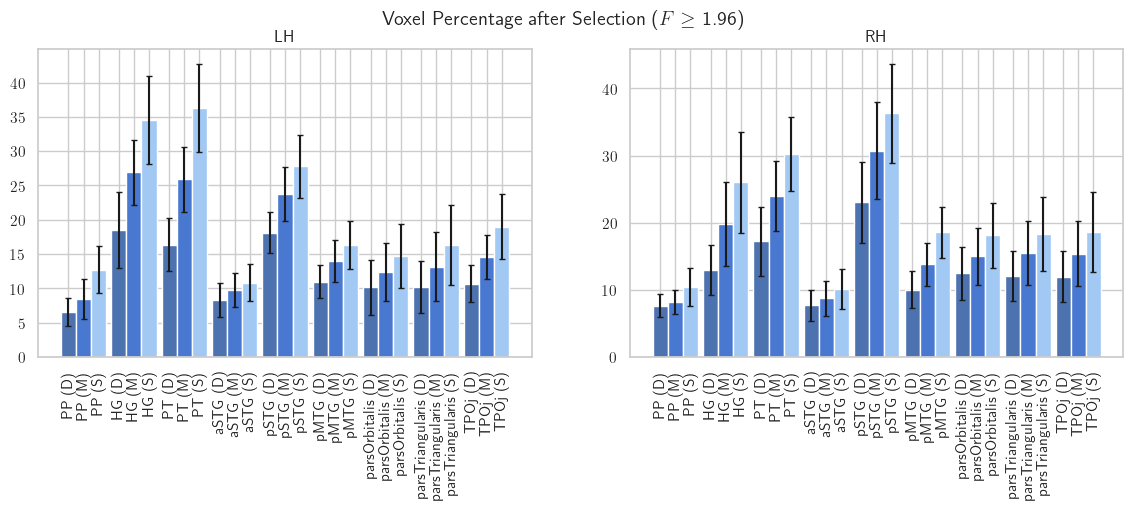

In [8]:
fig = plt.figure(figsize=(14,4))
palette = sns.color_palette()
palette1 = sns.color_palette("muted")
palette2 = sns.color_palette("pastel")

regions_layers_list = np.array([[region + ' (D)', region + ' (M)', region + ' (S)'] for region in regions]).ravel()

ax = plt.subplot(1,2,1)
voxel_counts_lh_l1 = {region:np.nanmean([dataset[subject]['LH'][region]['betas_selected']['L1'].shape[0]*100/dataset[subject]['LH'][region]['betas']['L1'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l1_se = {region:np.std([dataset[subject]['LH'][region]['betas_selected']['L1'].shape[0]*100/dataset[subject]['LH'][region]['betas']['L1'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l1_ci = [1.96 * (std_dev / np.sqrt(len(subjects))) for std_dev in voxel_counts_lh_l1_se.values()]
voxel_counts_lh_l2 = {region:np.nanmean([dataset[subject]['LH'][region]['betas_selected']['L2'].shape[0]*100/dataset[subject]['LH'][region]['betas']['L2'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l2_se = {region:np.std([dataset[subject]['LH'][region]['betas_selected']['L2'].shape[0]*100/dataset[subject]['LH'][region]['betas']['L2'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l2_ci = [1.96 * (std_dev / np.sqrt(len(subjects))) for std_dev in voxel_counts_lh_l2_se.values()]
voxel_counts_lh_l3 = {region:np.nanmean([dataset[subject]['LH'][region]['betas_selected']['L3'].shape[0]*100/dataset[subject]['LH'][region]['betas']['L3'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l3_se = {region:np.std([dataset[subject]['LH'][region]['betas_selected']['L3'].shape[0]*100/dataset[subject]['LH'][region]['betas']['L3'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_lh_l3_ci = [1.96 * (std_dev / np.sqrt(len(subjects))) for std_dev in voxel_counts_lh_l3_se.values()]

x_positions1 = np.arange(len(voxel_counts_lh_l1))
ax.bar(x=x_positions1, height=voxel_counts_lh_l1.values(), capsize=2, width=0.3, color=palette[0], yerr=voxel_counts_lh_l1_ci)
x_positions2 = x_positions1 + 0.3
ax.bar(x=x_positions2, height=voxel_counts_lh_l2.values(), capsize=2, width=0.3, color=palette1[0], yerr=voxel_counts_lh_l2_ci)
x_positions3 = x_positions1 + 0.6
ax.bar(x=x_positions3, height=voxel_counts_lh_l3.values(), capsize=2, width=0.3, color=palette2[0], yerr=voxel_counts_lh_l3_ci)
ax.set_xticks(np.sort(np.concatenate([x_positions1, x_positions2, x_positions3])), regions_layers_list)
plt.xticks(rotation=90)
ax.set_title('LH')

##############

regions_layers_list = np.array([[region + ' (D)', region + ' (M)', region + ' (S)'] for region in regions]).ravel()

ax = plt.subplot(1,2,2)

voxel_counts_rh_l1 = {region:np.nanmean([dataset[subject]['RH'][region]['betas_selected']['L1'].shape[0]*100/dataset[subject]['RH'][region]['betas']['L1'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_rh_l1_se = {region:np.std([dataset[subject]['RH'][region]['betas_selected']['L1'].shape[0]*100/dataset[subject]['RH'][region]['betas']['L1'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_rh_l1_ci = [1.96 * (std_dev / np.sqrt(len(subjects))) for std_dev in voxel_counts_rh_l1_se.values()]
voxel_counts_rh_l2 = {region:np.nanmean([dataset[subject]['RH'][region]['betas_selected']['L2'].shape[0]*100/dataset[subject]['RH'][region]['betas']['L2'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_rh_l2_se = {region:np.std([dataset[subject]['RH'][region]['betas_selected']['L2'].shape[0]*100/dataset[subject]['RH'][region]['betas']['L2'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_rh_l2_ci = [1.96 * (std_dev / np.sqrt(len(subjects))) for std_dev in voxel_counts_rh_l2_se.values()]
voxel_counts_rh_l3 = {region:np.nanmean([dataset[subject]['RH'][region]['betas_selected']['L3'].shape[0]*100/dataset[subject]['RH'][region]['betas']['L3'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_rh_l3_se = {region:np.std([dataset[subject]['RH'][region]['betas_selected']['L3'].shape[0]*100/dataset[subject]['RH'][region]['betas']['L3'].shape[0] for subject in subjects]) for region in regions}
voxel_counts_rh_l3_ci = [1.96 * (std_dev / np.sqrt(len(subjects))) for std_dev in voxel_counts_rh_l3_se.values()]

x_positions1 = np.arange(len(voxel_counts_rh_l1))
ax.bar(x=x_positions1, height=voxel_counts_rh_l1.values(), capsize=2, width=0.3, color=palette[0], yerr=voxel_counts_rh_l1_ci)
ax.bar(x=x_positions2, height=voxel_counts_rh_l2.values(), capsize=2, width=0.3, color=palette1[0], yerr=voxel_counts_rh_l2_ci)
ax.bar(x=x_positions3, height=voxel_counts_rh_l3.values(), capsize=2, width=0.3, color=palette2[0], yerr=voxel_counts_rh_l3_ci)
ax.set_xticks(np.sort(np.concatenate([x_positions1, x_positions2, x_positions3])), regions_layers_list)
plt.xticks(rotation=90)
ax.set_title('RH')

plt.suptitle(r'Voxel Percentage after Selection ($F \geq$ ' + str(t_threshold) + ')')
plt.show()

---

# Plot Mean Activations

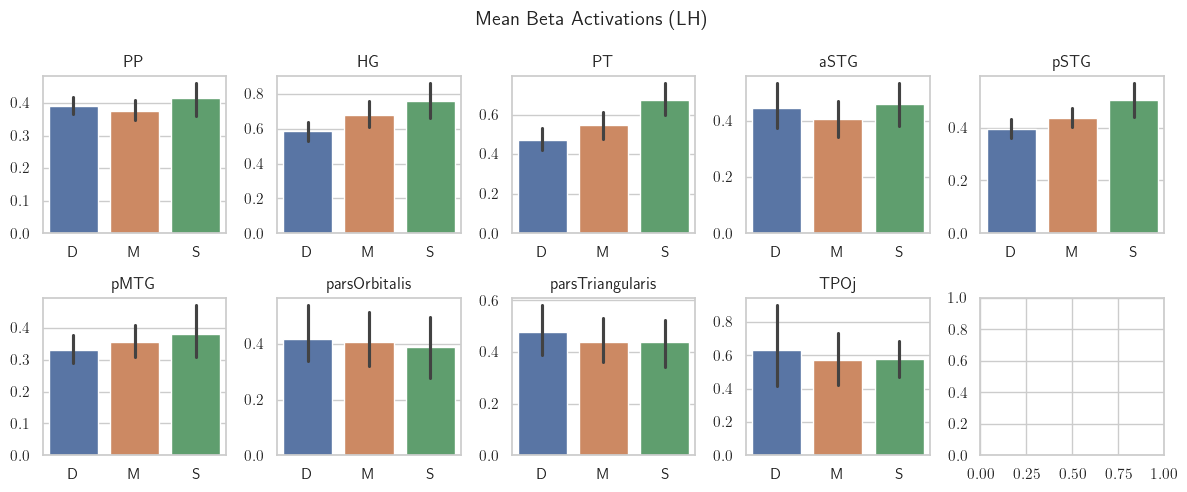

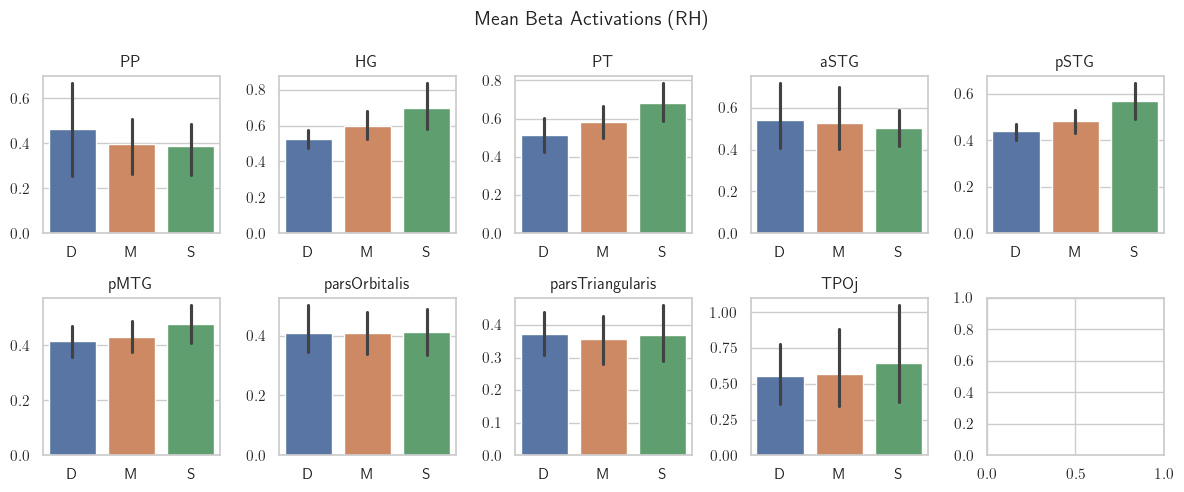

In [9]:
fig, ax = plt.subplots(2, 5, figsize=(12,5))

for region_idx, axis in enumerate(ax.ravel()):
    if region_idx==9:continue

    activations = {
        val: [np.nanmean(dataset[subject]['LH'][regions[region_idx]]['betas_selected'][f'L{idx+1}'].values) for subject in subjects]
        for idx, val in enumerate(['D', 'M', 'S'])
    }
    sns.barplot(activations, ax=axis)
    axis.set_title(regions[region_idx])

plt.suptitle('Mean Beta Activations (LH)')
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(2, 5, figsize=(12,5))

for region_idx, axis in enumerate(ax.ravel()):
    if region_idx==9:continue

    activations = {
        val: [np.nanmean(dataset[subject]['RH'][regions[region_idx]]['betas_selected'][f'L{idx+1}'].values) for subject in subjects]
        for idx, val in enumerate(['D', 'M', 'S'])
    }
    sns.barplot(activations, ax=axis)
    axis.set_title(regions[region_idx])

plt.suptitle('Mean Beta Activations (RH)')
plt.tight_layout()
plt.show()

In [10]:
def non_parametric_permutation_ttest(betas):
    n_subjects = betas.size
    permutation_matrix = np.array(list(itertools.product([1,-1], repeat=n_subjects))).T
    permutation_product = betas @ permutation_matrix
    p_val = (sum(abs(permutation_product[0]) <= abs(permutation_product[1:-1])) + 1) / (permutation_product.size)
    return p_val

---

# <center> $\Large\textbf{Congruent vs. Incongruent}$ </center>

**Test the effect of prediction error.**

In [90]:
regex1 = '_cong$'
regex2 = '_incong$'

layers = ['L1', 'L2', 'L3']

tstats = {}; pvals = {}; set1 = {};set2 = {}
for layer_name, layer_id in zip(['Deep', 'Middle', 'Superficial'], ['L1', 'L2', 'L3']):
    tstats[layer_id] = []; pvals[layer_id] = []; df_set1 = {}; df_set2 = {}
    for region in regions:
        df_set1[region] = []
        df_set2[region] = []
        for subject in subjects:
            stimuli = tbx.utils.extract_stimuli(subject)
            betas_l = tbx.utils.extract_condition_betas(stimuli=stimuli,
                                                        betas=dataset[subject]['LH'][region]['betas_selected'][layer_id].values.T,
                                                        stimulus_type='sound')
            betas_r = tbx.utils.extract_condition_betas(stimuli=stimuli,
                                                        betas=dataset[subject]['RH'][region]['betas_selected'][layer_id].values.T,
                                                        stimulus_type='sound')
            
            df_set1[region].append(np.mean([
                np.nanmean(betas_l.filter(regex=regex1).values),
                np.nanmean(betas_r.filter(regex=regex1).values)]))
            df_set2[region].append(np.mean([
                np.nanmean(betas_l.filter(regex=regex2).values),
                np.nanmean(betas_r.filter(regex=regex2).values)]))
    set1[layer_id] = df_set1
    set2[layer_id] = df_set2

all_non_parametric_pvals = np.array([[non_parametric_permutation_ttest(np.subtract(set2[layer][region], set1[layer][region])) for layer in layers] for region in regions])
all_non_parametric_pvals_flat = np.array(all_non_parametric_pvals).ravel()
reject_fdr, p_adjusted = fdrcorrection(all_non_parametric_pvals_flat)
p_adjusted = p_adjusted.reshape(np.array(all_non_parametric_pvals).shape)


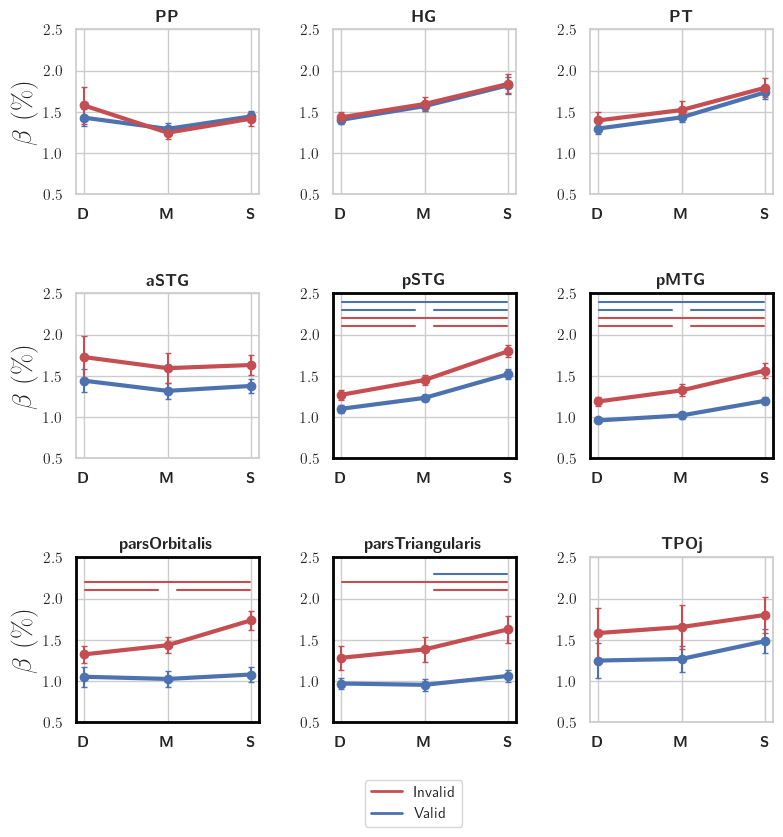

In [91]:

all_layer_pvals = []
for region in regions:
    for layerA, layerB in itertools.combinations(layers, 2):
        diff_betas_layerA = np.subtract(set2[layerA][region], set1[layerA][region]) # difference within layerA
        diff_betas_layerB = np.subtract(set2[layerB][region], set1[layerB][region]) # difference within layerB
        all_layer_pvals.append(non_parametric_permutation_ttest(diff_betas_layerA - diff_betas_layerB))


reject_fdr, p_layers_adjusted = fdrcorrection(all_layer_pvals)

all_non_parametric_pvals_for_layers = {}
idx = 0
for region in regions:
    all_non_parametric_pvals_for_layers[region] = {}
    for layerA, layerB in itertools.combinations(layers, 2):
        all_non_parametric_pvals_for_layers[region]['_'.join([layerA, layerB])] = p_layers_adjusted[idx]
        idx += 1


fig = plt.figure(figsize=(9, 9))
gs = gridspec.GridSpec(3, 3, height_ratios=[1, 1, 1], hspace=0.6, wspace=0.4)

ax1 = fig.add_subplot(gs[0, 0]) 
ax2 = fig.add_subplot(gs[0, 1]) 
ax3 = fig.add_subplot(gs[0, 2]) 
ax4 = fig.add_subplot(gs[1, 0]) 
ax5 = fig.add_subplot(gs[1, 1]) 
ax6 = fig.add_subplot(gs[1, 2]) 
ax7 = fig.add_subplot(gs[2, 0]) 
ax8 = fig.add_subplot(gs[2, 1]) 
ax9 = fig.add_subplot(gs[2, 2])

for idx, axis in enumerate(fig.get_axes()): # regions
    means1 = np.array([np.nanmean(set1[layer][regions[idx]]) for layer in layers])
    stderr1 = np.array([np.nanstd(set1[layer][regions[idx]]) for layer in layers])/np.sqrt(11)
    sns.lineplot(means1, ax=axis, c='b', linewidth=3)
    axis.errorbar(x=range(len(means1)), y=means1, yerr=stderr1, fmt='o', capsize=2, c='b')

    means2 = np.array([np.nanmean(set2[layer][regions[idx]]) for layer in layers])
    stderr2 = np.array([np.nanstd(set2[layer][regions[idx]]) for layer in layers])/np.sqrt(11)
    sns.lineplot(means2, ax=axis, c='r', linewidth=3)
    axis.errorbar(x=range(len(means2)), y=means2, yerr=stderr2, fmt='o', capsize=2, c='r')
                                     
#     for x, star in enumerate(tbx.viz.pvals2stars(p_adjusted[idx])):
#         if star == 'ns': continue
#         axis.text(x, 2.5, '*', ha='center', va='bottom', color='k', weight='bold', fontsize=20)
        
#     # layer statistics
#     for layer_comb in all_non_parametric_pvals_for_layers[regions[idx]]:
#         lA, lB = layer_comb.split('_')
#         xA, xB = int(lA[1])-1, int(lB[1])-1
#         p_layer = all_non_parametric_pvals_for_layers[regions[idx]][layer_comb]
#         star = tbx.viz.pvals2stars(p_layer)
#         if star != 'ns':
#             if xA==0 and xB==2:
#                 axis.plot([xA+.1,xB-.1], [2.2,2.2], c='k')
#                 axis.text((xB+xA)/2, 2.2, '*', ha='center', va='bottom', color='k', weight='bold', fontsize=20)
#                 axis.plot([xA+.1, xA+.1], [2.1,2.2], c='k')
#                 axis.plot([xB-.1, xB-.1], [2.1,2.2], c='k')
#             else:
#                 axis.plot([xA+.1,xB-.1], [2,2], c='k')
#                 axis.text((xB+xA)/2, 2, '*', ha='center', va='bottom', color='k', weight='bold', fontsize=20)
#                 axis.plot([xA+.1, xA+.1], [2,1.9], c='k')
#                 axis.plot([xB-.1, xB-.1], [2,1.9], c='k')
                
    axis.set_xticks([0,1,2], [r'$\textbf{D}$', r'$\textbf{M}$', r'$\textbf{S}$'])
    axis.set_ylim([0.5, 2.5])
    if idx in [0,3,6]:
        axis.set_ylabel(r'$\mathbf{\beta\ (\%)}$', fontsize=20)
    axis.set_title(r'$\textbf{'+regions[idx]+r'}$')
    
    # make border thicker when there is an interaction
    if regions[idx] in ['pSTG', 'pMTG', 'parsOrbitalis', 'parsTriangularis']:
        for spine in axis.spines.values():
            spine.set_linewidth(2)
            spine.set_color('black')
    # add layer interactions
    if regions[idx] == 'pSTG':
        axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5)
        axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5)
        axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5)
        axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5)
        axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5)
        axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5)
    if regions[idx] == 'pMTG':
        axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5)
        axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5)
        axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5)
        axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5)
        axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5)
        axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5)
    if regions[idx] == 'parsOrbitalis':
        axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5)
        axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5)
        axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5)
    if regions[idx] == 'parsTriangularis':
        axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5)
        axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5)
        axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5)
    # if regions[idx] in ['PP', 'HG', 'PT', 'aSTG', 'TPOj']:
    #     axis.text(1.95, 2.35, '*', color='k', weight='bold', fontsize=20)

blue_line = mlines.Line2D([], [], color='b', linestyle='-', linewidth=2, label='Valid')
red_line = mlines.Line2D([], [], color='r', linestyle='-', linewidth=2, label='Invalid')
fig.legend(handles=[red_line, blue_line], loc='center', bbox_to_anchor=(.5, 0.02))

# Mean Activations of Congruent vs. Invalid Trials (11 Subjects, Averaged Hemisphere, Non-Parametric FDR Corrected
plt.savefig('./figures/univariate_laminar_cong_incong_nonparametric_fdr_friedman.png', dpi=300, bbox_inches='tight')
plt.show()

In [92]:
from scipy.stats import ttest_rel
ttest_rel(diff_betas_layerA, diff_betas_layerB)

TtestResult(statistic=1.4934115297125083, pvalue=0.1661941254808135, df=10)

In [93]:
region = 'parsOrbitalis'

means_diff = np.array([np.mean(np.array(set2[layer][region]) - np.array(set1[layer][region])) for layer in layers])
stderr_diff = np.array([np.std(np.array(set2[layer][region]) - np.array(set1[layer][region])) for layer in layers])/np.sqrt(11)
sns.lineplot(means_diff, ax=axis, c=palette[-2], linewidth=3)
axis.errorbar(x=range(len(means_diff)), y=means_diff, yerr=stderr_diff, fmt='o', capsize=2, c=palette[-2])

# friedman
diffMeas = np.array([set2[item][region] for item in ['L1', 'L2', 'L3']]) - np.array([set1[item][region] for item in ['L1', 'L2', 'L3']]).astype(np.float64)
friedman = friedmanchisquare(*diffMeas)
print(friedman)
# apply multcompare
eng = matlab.engine.start_matlab()
diffMeas_ml = matlab.double(diffMeas.tolist())
eng.workspace['diffMeas'] = diffMeas_ml
eng.eval("[p,tbl,stats] = friedman(diffMeas',1);", nargout=0)
c = eng.eval("multcompare(stats);", nargout=1)
c_py = np.array(c)
eng.quit()
print(pd.DataFrame(c_py[:,2:], index=['D-M', 'D-S', 'M-S'], columns=['Lower CI', 'Mean rank Diff', 'Upper CI', 'p-value']).to_latex())


FriedmanchisquareResult(statistic=22.0, pvalue=1.6701700790245663e-05)
Note: Intervals can be used for testing but are not simultaneous confidence intervals.
\begin{tabular}{lrrrr}
\toprule
 & Lower CI & Mean rank Diff & Upper CI & p-value \\
\midrule
D-M & -1.999357 & -1.000000 & -0.000643 & 0.049810 \\
D-S & -2.999357 & -2.000000 & -1.000643 & 0.000008 \\
M-S & -1.999357 & -1.000000 & -0.000643 & 0.049810 \\
\bottomrule
\end{tabular}



<Axes: >

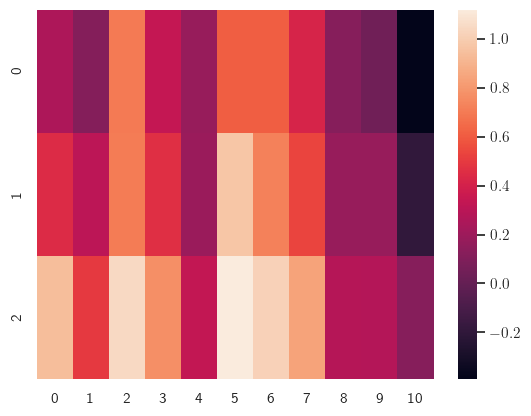

In [94]:
sns.heatmap(diffMeas)

In [95]:
from pprint import pprint
pprint(diffMeas.T)

array([[ 0.25519818,  0.44198275,  0.93640363],
       [ 0.11206841,  0.30697429,  0.49867511],
       [ 0.69639564,  0.70171034,  1.04526615],
       [ 0.33986801,  0.46206617,  0.76772261],
       [ 0.18043387,  0.19082916,  0.32916534],
       [ 0.60763967,  0.96948957,  1.11917031],
       [ 0.60798019,  0.72360176,  1.01422226],
       [ 0.41428649,  0.53321671,  0.83676147],
       [ 0.11857301,  0.18045348,  0.28495514],
       [ 0.04233229,  0.17913282,  0.28053468],
       [-0.39152718, -0.19603968,  0.11681759]])


In [96]:
# do manual wilcoxon
region = 'parsOrbitalis'
from scipy.stats import wilcoxon
print(wilcoxon(diffMeas[0], diffMeas[1]))
print(wilcoxon(diffMeas[0], diffMeas[2]))
print(wilcoxon(diffMeas[1], diffMeas[2]))

WilcoxonResult(statistic=0.0, pvalue=0.0009765625)
WilcoxonResult(statistic=0.0, pvalue=0.0009765625)
WilcoxonResult(statistic=0.0, pvalue=0.0009765625)


FriedmanchisquareResult(statistic=9.454545454545467, pvalue=0.008850576089052042)
Note: Intervals can be used for testing but are not simultaneous confidence intervals.
\begin{tabular}{lrrrr}
\toprule
 & Lower CI & Mean rank Diff & Upper CI & p-value \\
\midrule
D-M & -1.908448 & -0.909091 & 0.090266 & 0.083462 \\
D-S & -2.272085 & -1.272727 & -0.273370 & 0.007987 \\
M-S & -1.362994 & -0.363636 & 0.635721 & 0.670082 \\
\bottomrule
\end{tabular}

FriedmanchisquareResult(statistic=8.909090909090907, pvalue=0.011625603038838514)
Note: Intervals can be used for testing but are not simultaneous confidence intervals.
\begin{tabular}{lrrrr}
\toprule
 & Lower CI & Mean rank Diff & Upper CI & p-value \\
\midrule
D-M & -1.635721 & -0.636364 & 0.362994 & 0.294540 \\
D-S & -2.272085 & -1.272727 & -0.273370 & 0.007987 \\
M-S & -1.635721 & -0.636364 & 0.362994 & 0.294540 \\
\bottomrule
\end{tabular}

FriedmanchisquareResult(statistic=22.0, pvalue=1.6701700790245663e-05)
Note: Intervals can be used f

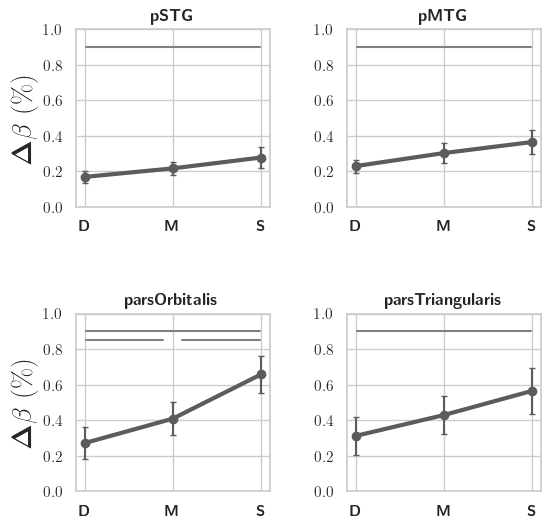

In [97]:
regions_selected = ['pSTG', 'pMTG', 'parsOrbitalis', 'parsTriangularis']
palette = sns.color_palette('Grays')

all_layer_pvals = []
for region in regions_selected:
    for layerA, layerB in itertools.combinations(layers, 2):
        diff_betas_layerA = np.subtract(set2[layerA][region], set1[layerA][region]) # difference within layerA
        diff_betas_layerB = np.subtract(set2[layerB][region], set1[layerB][region]) # difference within layerB
        all_layer_pvals.append(non_parametric_permutation_ttest(diff_betas_layerA - diff_betas_layerB))


reject_fdr, p_layers_adjusted = fdrcorrection(all_layer_pvals)

all_non_parametric_pvals_for_layers = {}
idx = 0
for region in regions_selected:
    all_non_parametric_pvals_for_layers[region] = {}
    for layerA, layerB in itertools.combinations(layers, 2):
        all_non_parametric_pvals_for_layers[region]['_'.join([layerA, layerB])] = p_layers_adjusted[idx]
        idx += 1


fig = plt.figure(figsize=(6, 6))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], hspace=0.6, wspace=0.4)

ax1 = fig.add_subplot(gs[0, 0]) 
ax2 = fig.add_subplot(gs[0, 1]) 
ax4 = fig.add_subplot(gs[1, 0]) 
ax5 = fig.add_subplot(gs[1, 1]) 


for idx, axis in enumerate(fig.get_axes()): # regions_selected
    means_diff = np.array([np.mean(np.array(set2[layer][regions_selected[idx]]) - np.array(set1[layer][regions_selected[idx]])) for layer in layers])
    stderr_diff = np.array([np.std(np.array(set2[layer][regions_selected[idx]]) - np.array(set1[layer][regions_selected[idx]])) for layer in layers])/np.sqrt(11)
    sns.lineplot(means_diff, ax=axis, c=palette[-2], linewidth=3)
    axis.errorbar(x=range(len(means_diff)), y=means_diff, yerr=stderr_diff, fmt='o', capsize=2, c=palette[-2])
    
    # friedman
    diffMeas = np.array([set2[item][regions_selected[idx]] for item in ['L1', 'L2', 'L3']]) - np.array([set1[item][regions_selected[idx]] for item in ['L1', 'L2', 'L3']]).astype(np.float64)
    friedman = friedmanchisquare(*diffMeas)
    print(friedman)
    # apply multcompare
    eng = matlab.engine.start_matlab()
    diffMeas_ml = matlab.double(diffMeas.tolist())
    eng.workspace['diffMeas'] = diffMeas_ml
    eng.eval("[p,tbl,stats] = friedman(diffMeas',1);", nargout=0)
    c = eng.eval("multcompare(stats);", nargout=1)
    c_py = np.array(c)
    eng.quit()
    print(pd.DataFrame(c_py[:,2:], index=['D-M', 'D-S', 'M-S'], columns=['Lower CI', 'Mean rank Diff', 'Upper CI', 'p-value']).to_latex())
    
    if regions_selected[idx] == 'pSTG':
        axis.axhline(0.9, 0.05, 0.95, c='gray', linewidth=1.5) # D-S
        # axis.axhline(0.85, 0.05, 0.45, c='gray', linewidth=1.5) # D-M
        # axis.axhline(0.25, 0.55, 0.95, c='gray', linewidth=1.5) # M-S
    if regions_selected[idx] == 'pMTG':
        axis.axhline(0.9, 0.05, 0.95, c='gray', linewidth=1.5) # D-S
        # axis.axhline(0.85, 0.05, 0.45, c='gray', linewidth=1.5) # D-M
        # axis.axhline(0.25, 0.55, 0.95, c='gray', linewidth=1.5) # M-S
    if regions_selected[idx] == 'parsOrbitalis':
        axis.axhline(0.9, 0.05, 0.95, c='gray', linewidth=1.5) # D-S
        axis.axhline(0.85, 0.05, 0.45, c='gray', linewidth=1.5) # D-M
        axis.axhline(0.85, 0.55, 0.95, c='gray', linewidth=1.5) # M-S
    if regions_selected[idx] == 'parsTriangularis':
        axis.axhline(0.9, 0.05, 0.95, c='gray', linewidth=1.5) # D-S
        # axis.axhline(0.85, 0.05, 0.45, c='gray', linewidth=1.5) # D-M
        # axis.axhline(0.85, 0.55, 0.95, c='gray', linewidth=1.5) # M-S
    
    axis.set_xticks([0,1,2], [r'$\textbf{D}$', r'$\textbf{M}$', r'$\textbf{S}$'])
    axis.set_ylim([0.0, 1.])
    if idx in [0,2]:
        axis.set_ylabel(r'$\mathbf{\Delta\beta\ (\%)}$', fontsize=20)
    axis.set_title(r'$\textbf{'+regions_selected[idx]+r'}$')

# blue_line = mlines.Line2D([], [], color='b', linestyle='-', linewidth=2, label='Valid')
# red_line = mlines.Line2D([], [], color='r', linestyle='-', linewidth=2, label='Invalid')
# fig.legend(handles=[red_line, blue_line], loc='center', bbox_to_anchor=(.5, 0.02))

# Mean Activations of Congruent vs. Invalid Trials (11 Subjects, Averaged Hemisphere, Non-Parametric FDR Corrected
plt.savefig('./figures/univariate_laminar_cong_incong_nonparametric_fdr_friedman_posthoc.png', dpi=300, bbox_inches='tight')
plt.show()

In [98]:
diffs = []
for idx, axis in enumerate(fig.get_axes()): # regions_selected
    means_diff = np.array([np.mean(np.array(set2[layer][regions_selected[idx]]) - np.array(set1[layer][regions_selected[idx]])) for layer in layers])
    stderr_diff = np.array([np.std(np.array(set2[layer][regions_selected[idx]]) - np.array(set1[layer][regions_selected[idx]])) for layer in layers])/np.sqrt(11)
    sns.lineplot(means_diff, ax=axis, c=palette[-2], linewidth=3)
    axis.errorbar(x=range(len(means_diff)), y=means_diff, yerr=stderr_diff, fmt='o', capsize=2, c=palette[-2])
    
    # friedman
    diffMeas = np.array([set2[item][regions_selected[idx]] for item in ['L1', 'L2', 'L3']]) - np.array([set1[item][regions_selected[idx]] for item in ['L1', 'L2', 'L3']]).astype(np.float64)
    
    print(np.mean(diffMeas, axis=1), '\t', regions_selected[idx])
    diffs.append(np.mean(diffMeas, axis=1))
diffs = np.array(diffs)

np.min(diffs), np.max(diffs)

[0.16910682 0.21714486 0.27799502] 	 pSTG
[0.23014389 0.30344145 0.36542048] 	 pMTG
[0.27120442 0.40849249 0.65724494] 	 parsOrbitalis
[0.3118356  0.4290978  0.56491847] 	 parsTriangularis


(0.16910681941292502, 0.6572449369864031)

In [139]:
# (0.16910681941292502, 0.6572449369864031
# (-1.1287472214211116, 0.6597942059690302
# (-0.49109694124622777, -0.08562372760339217

scales = [0.16910681941292502, 0.6572449369864031, -1.1287472214211116, 0.6597942059690302, -0.49109694124622777, -0.08562372760339217]
mincol, maxcol = np.min(scales), np.max(scales)
mincol, maxcol

maxcol = 0.4
mincol = 0.1

In [140]:
from copy import deepcopy

smp_head, smp_data = bvbabel.smp.read_smp('/mnt/hdd2/associative_learning/paper_draft_v1/paper_draft_ALPHA/templates/group_patches_LH_template.smp')
smp_data[smp_data<6] = 0
smp_data[smp_data>0] = 6

In [175]:
all_regs

['HG',
 'PP',
 'PT',
 'aSTG',
 'pSTG',
 'pMTG',
 'TPOj',
 'parsOrbitalis',
 'parsTriangularis']

In [141]:
all_regs = [entry['Name'] for entry in smp_head['Map']]

dep = ['pSTG', 'pMTG', 'parsOrbitalis', 'parsTriangularis']
mid = ['pSTG', 'pMTG', 'parsOrbitalis', 'parsTriangularis']
dep = ['pSTG', 'pMTG', 'parsOrbitalis', 'parsTriangularis']

# Superficial
_, indcs, _ = np.intersect1d(all_regs, dep, return_indices=True)
smp_head_cp = deepcopy(smp_head)
smp_head_cp['Nr maps'] = len(indcs)
smp_head_cp['Map'] = list(np.array(smp_head_cp['Map'])[indcs])
data = deepcopy(smp_data[:, indcs])

for idx, tval in enumerate(diffs[:,0]):
    data[:, idx][data[:, idx]==6] = tval
    smp_head_cp['Map'][idx]['Threshold min'] = mincol
    smp_head_cp['Map'][idx]['Threshold max'] = maxcol
print(smp_head_cp['Map'][idx]['Threshold min'], smp_head_cp['Map'][idx]['Threshold max'])
bvbabel.smp.write_smp('/mnt/hdd2/associative_learning/paper_draft_v1/figures/group_patches_LH_univariate_valid_invalid_dep.smp', smp_head_cp, data)

# Middle
_, indcs, _ = np.intersect1d(all_regs, mid, return_indices=True)
smp_head_cp = deepcopy(smp_head)
smp_head_cp['Nr maps'] = len(indcs)
smp_head_cp['Map'] = list(np.array(smp_head_cp['Map'])[indcs])
data = deepcopy(smp_data[:, indcs])

for idx, tval in enumerate(diffs[:,1]):
    data[:, idx][data[:, idx]==6] = tval
    smp_head_cp['Map'][idx]['Threshold min'] = mincol
    smp_head_cp['Map'][idx]['Threshold max'] = maxcol
print(smp_head_cp['Map'][idx]['Threshold min'], smp_head_cp['Map'][idx]['Threshold max'])
bvbabel.smp.write_smp('/mnt/hdd2/associative_learning/paper_draft_v1/figures/group_patches_LH_univariate_valid_invalid_mid.smp', smp_head_cp, data)

# Deep
_, indcs, _ = np.intersect1d(all_regs, sup, return_indices=True)
smp_head_cp = deepcopy(smp_head)
smp_head_cp['Nr maps'] = len(indcs)
smp_head_cp['Map'] = list(np.array(smp_head_cp['Map'])[indcs])
data = deepcopy(smp_data[:, indcs])

for idx, tval in enumerate(diffs[:,2]):
    data[:, idx][data[:, idx]==6] = tval
    smp_head_cp['Map'][idx]['Threshold min'] = mincol
    smp_head_cp['Map'][idx]['Threshold max'] = maxcol
print(smp_head_cp['Map'][idx]['Threshold min'], smp_head_cp['Map'][idx]['Threshold max'])
bvbabel.smp.write_smp('/mnt/hdd2/associative_learning/paper_draft_v1/figures/group_patches_LH_univariate_valid_invalid_sup.smp', smp_head_cp, data)


0.1 0.4
0.1 0.4
0.1 0.4


In [133]:
import colorsys
import matplotlib.pyplot as plt

def hex_to_rgb(hex_color):
    """Convert hex color to an RGB tuple."""
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

def generate_gradient_hsv(colors, steps=100):
    """
    Generate a gradient passing through multiple RGB colors using HSV interpolation.
    
    Parameters:
        colors (list of tuples): List of RGB colors [(R, G, B), ...] with values between 0-255.
        steps (int): The total number of gradient steps.
        
    Returns:
        List of RGB tuples forming the gradient.
    """
    num_segments = len(colors) - 1
    steps_per_segment = steps // num_segments
    gradient = []
    
    for i in range(num_segments):
        color1 = colors[i]
        color2 = colors[i + 1]
        
        hsv1 = colorsys.rgb_to_hsv(color1[0] / 255.0, color1[1] / 255.0, color1[2] / 255.0)
        hsv2 = colorsys.rgb_to_hsv(color2[0] / 255.0, color2[1] / 255.0, color2[2] / 255.0)
        
        if abs(hsv2[0] - hsv1[0]) > 0.5:
            if hsv1[0] > hsv2[0]:
                hsv2 = (hsv2[0] + 1, hsv2[1], hsv2[2])
            else:
                hsv1 = (hsv1[0] + 1, hsv1[1], hsv1[2])
        
        for j in range(steps_per_segment):
            t = j / steps_per_segment
            hue = (hsv1[0] + (hsv2[0] - hsv1[0]) * t) % 1
            saturation = hsv1[1] + (hsv2[1] - hsv1[1]) * t
            value = hsv1[2] + (hsv2[2] - hsv1[2]) * t
            
            r, g, b = colorsys.hsv_to_rgb(hue, saturation, value)
            gradient.append((int(r * 255), int(g * 255), int(b * 255)))
    
    return gradient

def display_gradient(gradient, fn):
    """Display the gradient using Matplotlib."""
    fig, ax = plt.subplots(figsize=(10, 1))
    ax.imshow([gradient], extent=[0, len(gradient), 0, 1], aspect='auto')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.savefig(fn, dpi=300)
    plt.show()

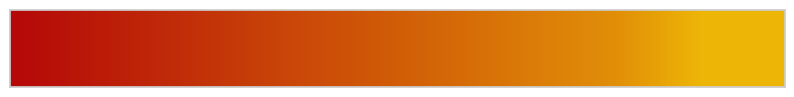

In [143]:
# hex_colors = np.array(['087bed','086ee0','0861d3','0854c7','0848ba','083aae','082ea1','082194','081588','08087b','b50808','bb1b08','c12e08','c84208','ce5408','d46708','db7b08','e18e08','e7a108','edb508'])#[::-1]
hex_colors = np.array(['b50808','bb1b08','c12e08','c84208','ce5408','d46707','db7b08','e18e08','edb507','edb507'])#[::-1]
colors = [hex_to_rgb(hex_color) for hex_color in hex_colors]
steps = 2000

gradient = generate_gradient_hsv(colors, steps)
display_gradient(gradient, '/mnt/hdd2/associative_learning/paper_draft_v1/figures/gradient_valid_invalid.png')

---

# <center> $\Large\textbf{Congruent vs. Omitted}$ </center>

**Test the effect of prediction error.**

In [200]:
regex1 = '_cong$'
regex2 = '^(?!random).*_omis$'

layers = ['L1', 'L2', 'L3']

tstats = {}; pvals = {}; set1 = {};set2 = {}
for layer_name, layer_id in zip(['Deep', 'Middle', 'Superficial'], ['L1', 'L2', 'L3']):
    tstats[layer_id] = []; pvals[layer_id] = []; df_set1 = {}; df_set2 = {}
    for region in regions:
        df_set1[region] = []
        df_set2[region] = []
        for subject in subjects:
            stimuli = tbx.utils.extract_stimuli(subject)
            betas_l = tbx.utils.extract_condition_betas(stimuli=stimuli,
                                                        betas=dataset[subject]['LH'][region]['betas_selected'][layer_id].values.T,
                                                        stimulus_type='sound')
            betas_r = tbx.utils.extract_condition_betas(stimuli=stimuli,
                                                        betas=dataset[subject]['RH'][region]['betas_selected'][layer_id].values.T,
                                                        stimulus_type='sound')
            
            df_set1[region].append(np.mean([
                np.nanmean(betas_l.filter(regex=regex1).values),
                np.nanmean(betas_r.filter(regex=regex1).values)]))
            df_set2[region].append(np.mean([
                np.nanmean(betas_l.filter(regex=regex2).values),
                np.nanmean(betas_r.filter(regex=regex2).values)]))
    set1[layer_id] = df_set1
    set2[layer_id] = df_set2

all_non_parametric_pvals = np.array([[non_parametric_permutation_ttest(np.subtract(set2[layer][region], set1[layer][region])) for layer in layers] for region in regions])
all_non_parametric_pvals_flat = np.array(all_non_parametric_pvals).ravel()
reject_fdr, p_adjusted = fdrcorrection(all_non_parametric_pvals_flat)
p_adjusted = p_adjusted.reshape(np.array(all_non_parametric_pvals).shape)


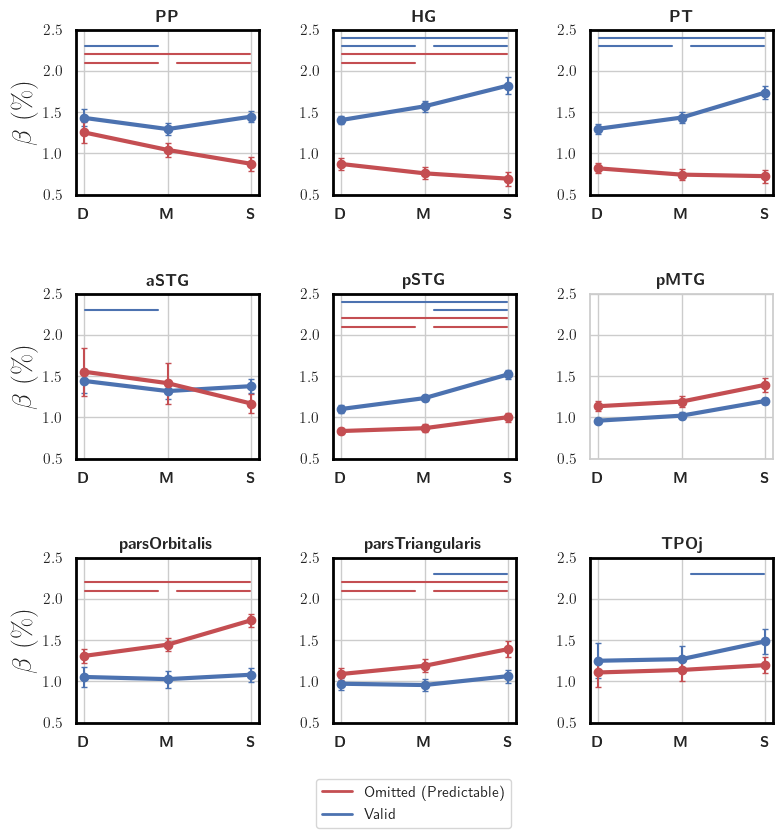

In [201]:

all_layer_pvals = []
for region in regions:
    for layerA, layerB in itertools.combinations(layers, 2):
        diff_betas_layerA = np.subtract(set2[layerA][region], set1[layerA][region]) # difference within layerA
        diff_betas_layerB = np.subtract(set2[layerB][region], set1[layerB][region]) # difference within layerB
        all_layer_pvals.append(non_parametric_permutation_ttest(diff_betas_layerA - diff_betas_layerB))


reject_fdr, p_layers_adjusted = fdrcorrection(all_layer_pvals)

all_non_parametric_pvals_for_layers = {}
idx = 0
for region in regions:
    all_non_parametric_pvals_for_layers[region] = {}
    for layerA, layerB in itertools.combinations(layers, 2):
        all_non_parametric_pvals_for_layers[region]['_'.join([layerA, layerB])] = p_layers_adjusted[idx]
        idx += 1


fig = plt.figure(figsize=(9, 9))
gs = gridspec.GridSpec(3, 3, height_ratios=[1, 1, 1], hspace=0.6, wspace=0.4)

ax1 = fig.add_subplot(gs[0, 0]) 
ax2 = fig.add_subplot(gs[0, 1]) 
ax3 = fig.add_subplot(gs[0, 2]) 
ax4 = fig.add_subplot(gs[1, 0]) 
ax5 = fig.add_subplot(gs[1, 1]) 
ax6 = fig.add_subplot(gs[1, 2]) 
ax7 = fig.add_subplot(gs[2, 0]) 
ax8 = fig.add_subplot(gs[2, 1]) 
ax9 = fig.add_subplot(gs[2, 2])

for idx, axis in enumerate(fig.get_axes()): # regions
    means1 = np.array([np.nanmean(set1[layer][regions[idx]]) for layer in layers])
    stderr1 = np.array([np.nanstd(set1[layer][regions[idx]]) for layer in layers])/np.sqrt(11)
    sns.lineplot(means1, ax=axis, c='b', linewidth=3)
    axis.errorbar(x=range(len(means1)), y=means1, yerr=stderr1, fmt='o', capsize=2, c='b')

    means2 = np.array([np.nanmean(set2[layer][regions[idx]]) for layer in layers])
    stderr2 = np.array([np.nanstd(set2[layer][regions[idx]]) for layer in layers])/np.sqrt(11)
    sns.lineplot(means2, ax=axis, c='r', linewidth=3)
    axis.errorbar(x=range(len(means2)), y=means2, yerr=stderr2, fmt='o', capsize=2, c='r')
                                     
    axis.set_xticks([0,1,2], [r'$\textbf{D}$', r'$\textbf{M}$', r'$\textbf{S}$'])
    axis.set_ylim([0.5, 2.5])
    if idx in [0,3,6]:
        axis.set_ylabel(r'$\mathbf{\beta\ (\%)}$', fontsize=20)
    axis.set_title(r'$\textbf{'+regions[idx]+r'}$')
    
    # make border thicker when there is an interaction
    if regions[idx] in ['PP', 'HG', 'PT', 'aSTG', 'pSTG', 'parsOrbitalis', 'parsTriangularis', 'TPOj']:
        for spine in axis.spines.values():
            spine.set_linewidth(2)
            spine.set_color('black')
    # add layer interactions
    if regions[idx] == 'PP':
        # axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
        axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
        # axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
        axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
        axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
        axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S
    if regions[idx] == 'HG':
        axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
        axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
        axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
        axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
        axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
        # axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S
    if regions[idx] == 'PT':
        axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
        axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
        axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
        # axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
        # axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
        # axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S
    if regions[idx] == 'aSTG':
        # axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
        axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
        # axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
        # axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
        # axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
        # axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S
    if regions[idx] == 'pSTG':
        axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
        # axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
        axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
        axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
        axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
        axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S
    if regions[idx] == 'parsOrbitalis':
        # axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
        # axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
        # axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
        axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
        axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
        axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S
    if regions[idx] == 'parsTriangularis':
        # axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
        # axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
        axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
        axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
        axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
        axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S
    if regions[idx] == 'TPOj':
        # axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
        # axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
        axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
        # axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
        # axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
        # axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S

    # if regions[idx] in ['pMTG']:
    #     axis.text(1.95, 2.35, '*', color='k', weight='bold', fontsize=20)

blue_line = mlines.Line2D([], [], color='b', linestyle='-', linewidth=2, label='Valid')
red_line = mlines.Line2D([], [], color='r', linestyle='-', linewidth=2, label='Omitted (Predictable)')
fig.legend(handles=[red_line, blue_line], loc='center', bbox_to_anchor=(.5, 0.02))

# Mean Activations of Congruent vs. Invalid Trials (11 Subjects, Averaged Hemisphere, Non-Parametric FDR Corrected
plt.savefig('./figures/univariate_laminar_cong_omis_nonparametric_fdr_friedman.png', dpi=300, bbox_inches='tight')
plt.show()

FriedmanchisquareResult(statistic=11.636363636363654, pvalue=0.0029730056986053306)
Note: Intervals can be used for testing but are not simultaneous confidence intervals.
\begin{tabular}{lrrrr}
\toprule
 & Lower CI & Mean rank Diff & Upper CI & p-value \\
\midrule
D-M & -0.272085 & 0.727273 & 1.726630 & 0.203037 \\
D-S & 0.455188 & 1.454545 & 2.453903 & 0.001871 \\
M-S & -0.272085 & 0.727273 & 1.726630 & 0.203037 \\
\bottomrule
\end{tabular}

FriedmanchisquareResult(statistic=15.27272727272728, pvalue=0.0004825801020447375)
Note: Intervals can be used for testing but are not simultaneous confidence intervals.
\begin{tabular}{lrrrr}
\toprule
 & Lower CI & Mean rank Diff & Upper CI & p-value \\
\midrule
D-M & 0.091552 & 1.090909 & 2.090266 & 0.028354 \\
D-S & 0.637006 & 1.636364 & 2.635721 & 0.000365 \\
M-S & -0.453903 & 0.545455 & 1.544812 & 0.406928 \\
\bottomrule
\end{tabular}

FriedmanchisquareResult(statistic=20.181818181818187, pvalue=4.145470838528921e-05)
Note: Intervals can be u

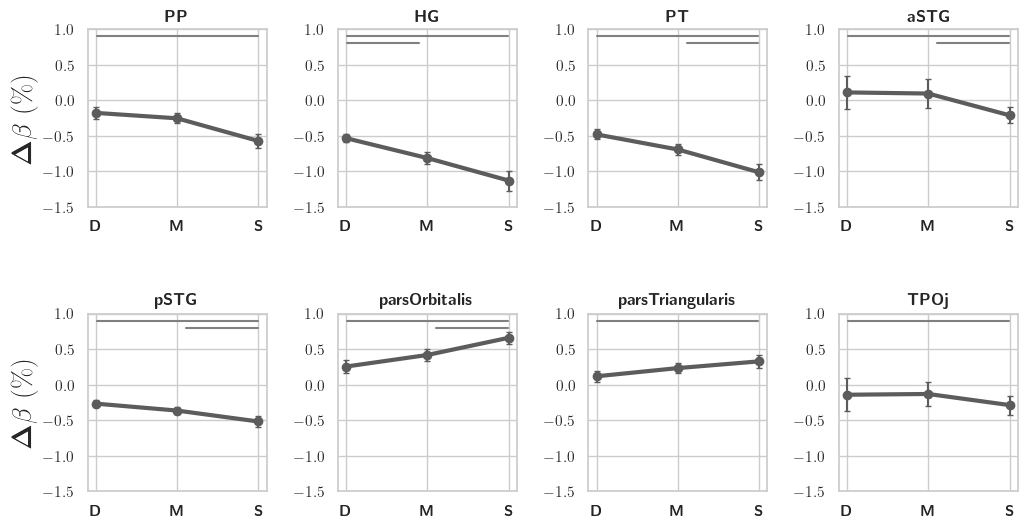

In [202]:
regions_selected = ['PP', 'HG', 'PT', 'aSTG', 'pSTG', 'parsOrbitalis', 'parsTriangularis', 'TPOj']
palette = sns.color_palette('Grays')

all_layer_pvals = []
for region in regions_selected:
    for layerA, layerB in itertools.combinations(layers, 2):
        diff_betas_layerA = np.subtract(set2[layerA][region], set1[layerA][region]) # difference within layerA
        diff_betas_layerB = np.subtract(set2[layerB][region], set1[layerB][region]) # difference within layerB
        all_layer_pvals.append(non_parametric_permutation_ttest(diff_betas_layerA - diff_betas_layerB))


reject_fdr, p_layers_adjusted = fdrcorrection(all_layer_pvals)

all_non_parametric_pvals_for_layers = {}
idx = 0
for region in regions_selected:
    all_non_parametric_pvals_for_layers[region] = {}
    for layerA, layerB in itertools.combinations(layers, 2):
        all_non_parametric_pvals_for_layers[region]['_'.join([layerA, layerB])] = p_layers_adjusted[idx]
        idx += 1


fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(2, 4, height_ratios=[1, 1], hspace=0.6, wspace=0.4)

ax1 = fig.add_subplot(gs[0, 0]) 
ax2 = fig.add_subplot(gs[0, 1]) 
ax3 = fig.add_subplot(gs[0, 2]) 
ax4 = fig.add_subplot(gs[0, 3]) 
ax5 = fig.add_subplot(gs[1, 0]) 
ax6 = fig.add_subplot(gs[1, 1]) 
ax7 = fig.add_subplot(gs[1, 2]) 
ax8 = fig.add_subplot(gs[1, 3]) 

for idx, axis in enumerate(fig.get_axes()): # regions_selected
    means_diff = np.array([np.nanmean(np.array(set2[layer][regions_selected[idx]]) - np.array(set1[layer][regions_selected[idx]])) for layer in layers])
    stderr_diff = np.array([np.nanstd(np.array(set2[layer][regions_selected[idx]]) - np.array(set1[layer][regions_selected[idx]])) for layer in layers])/np.sqrt(11)
    sns.lineplot(means_diff, ax=axis, c=palette[-2], linewidth=3)
    axis.errorbar(x=range(len(means_diff)), y=means_diff, yerr=stderr_diff, fmt='o', capsize=2, c=palette[-2])
    
    friedman
    diffMeas = np.array([set2[item][regions_selected[idx]] for item in ['L1', 'L2', 'L3']]) - np.array([set1[item][regions_selected[idx]] for item in ['L1', 'L2', 'L3']])
    friedman = friedmanchisquare(*diffMeas)
    print(friedman)
    # apply multcompare
    eng = matlab.engine.start_matlab()
    diffMeas_ml = matlab.double(diffMeas.tolist())
    eng.workspace['diffMeas'] = diffMeas_ml
    eng.eval("[p,tbl,stats] = friedman(diffMeas',1);", nargout=0)
    c = eng.eval("multcompare(stats);", nargout=1)
    c_py = np.array(c)
    eng.quit()
    print(pd.DataFrame(c_py[:,2:], index=['D-M', 'D-S', 'M-S'], columns=['Lower CI', 'Mean rank Diff', 'Upper CI', 'p-value']).to_latex())

    if regions_selected[idx] == 'PP':
        axis.axhline(0.9, 0.05, 0.95, c='gray', linewidth=1.5) # D-S
        # axis.axhline(0.8, 0.05, 0.45, c='gray', linewidth=1.5) # D-M
        # axis.axhline(0.8, 0.55, 0.95, c='gray', linewidth=1.5) # M-S
    if regions_selected[idx] == 'HG':
        axis.axhline(0.9, 0.05, 0.95, c='gray', linewidth=1.5) # D-S
        axis.axhline(0.8, 0.05, 0.45, c='gray', linewidth=1.5) # D-M
        # axis.axhline(0.8, 0.55, 0.95, c='gray', linewidth=1.5) # M-S
    if regions_selected[idx] == 'PT':
        axis.axhline(0.9, 0.05, 0.95, c='gray', linewidth=1.5) # D-S
        # axis.axhline(0.8, 0.05, 0.45, c='gray', linewidth=1.5) # D-M
        axis.axhline(0.8, 0.55, 0.95, c='gray', linewidth=1.5) # M-S
    if regions_selected[idx] == 'aSTG':
        axis.axhline(0.9, 0.05, 0.95, c='gray', linewidth=1.5) # D-S
        # axis.axhline(0.8, 0.05, 0.45, c='gray', linewidth=1.5) # D-M
        axis.axhline(0.8, 0.55, 0.95, c='gray', linewidth=1.5) # M-S
    if regions_selected[idx] == 'pSTG':
        axis.axhline(0.9, 0.05, 0.95, c='gray', linewidth=1.5) # D-S
        # axis.axhline(0.8, 0.05, 0.45, c='gray', linewidth=1.5) # D-M
        axis.axhline(0.8, 0.55, 0.95, c='gray', linewidth=1.5) # M-S
    if regions_selected[idx] == 'parsOrbitalis':
        axis.axhline(0.9, 0.05, 0.95, c='gray', linewidth=1.5) # D-S
        # axis.axhline(0.8, 0.05, 0.45, c='gray', linewidth=1.5) # D-M
        axis.axhline(0.8, 0.55, 0.95, c='gray', linewidth=1.5) # M-S
    if regions_selected[idx] == 'parsTriangularis':
        axis.axhline(0.9, 0.05, 0.95, c='gray', linewidth=1.5) # D-S
        # axis.axhline(0.8, 0.05, 0.45, c='gray', linewidth=1.5) # D-M
        # axis.axhline(0.8, 0.55, 0.95, c='gray', linewidth=1.5) # M-S
    if regions_selected[idx] == 'TPOj':
        axis.axhline(0.9, 0.05, 0.95, c='gray', linewidth=1.5) # D-S
        # axis.axhline(0.8, 0.05, 0.45, c='gray', linewidth=1.5) # D-M
        # axis.axhline(0.8, 0.55, 0.95, c='gray', linewidth=1.5) # M-S
    
    axis.set_xticks([0,1,2], [r'$\textbf{D}$', r'$\textbf{M}$', r'$\textbf{S}$'])
    axis.set_ylim([-1.5, 1.0])
    if idx in [0,4]:
        axis.set_ylabel(r'$\mathbf{\Delta\beta\ (\%)}$', fontsize=20)
    axis.set_title(r'$\textbf{'+regions_selected[idx]+r'}$')

# blue_line = mlines.Line2D([], [], color='b', linestyle='-', linewidth=2, label='Valid')
# red_line = mlines.Line2D([], [], color='r', linestyle='-', linewidth=2, label='Invalid')
# fig.legend(handles=[red_line, blue_line], loc='center', bbox_to_anchor=(.5, 0.02))

# Mean Activations of Congruent vs. Invalid Trials (11 Subjects, Averaged Hemisphere, Non-Parametric FDR Corrected
plt.savefig('./figures/univariate_laminar_cong_omis_nonparametric_fdr_friedman_posthoc.png', dpi=300, bbox_inches='tight')
plt.show()

In [203]:
diffs = []
for idx, axis in enumerate(fig.get_axes()): # regions_selected
    means_diff = np.array([np.mean(np.array(set2[layer][regions_selected[idx]]) - np.array(set1[layer][regions_selected[idx]])) for layer in layers])
    stderr_diff = np.array([np.std(np.array(set2[layer][regions_selected[idx]]) - np.array(set1[layer][regions_selected[idx]])) for layer in layers])/np.sqrt(11)
    sns.lineplot(means_diff, ax=axis, c=palette[-2], linewidth=3)
    axis.errorbar(x=range(len(means_diff)), y=means_diff, yerr=stderr_diff, fmt='o', capsize=2, c=palette[-2])
    
    # friedman
    diffMeas = np.array([set2[item][regions_selected[idx]] for item in ['L1', 'L2', 'L3']]) - np.array([set1[item][regions_selected[idx]] for item in ['L1', 'L2', 'L3']]).astype(np.float64)
    
    print(np.mean(diffMeas, axis=1), '\t', regions_selected[idx])
    diffs.append(np.mean(diffMeas, axis=1))
diffs = np.array(diffs)
print(diffs.shape)

np.min(diffs), np.max(diffs)

[-0.17643747 -0.25264215 -0.5716905 ] 	 PP
[-0.53255447 -0.81236371 -1.12874722] 	 HG
[-0.47925407 -0.69140491 -1.01252943] 	 PT
[ 0.11157262  0.09584089 -0.21016432] 	 aSTG
[-0.26698901 -0.36451044 -0.51826882] 	 pSTG
[0.25502221 0.41788249 0.65979421] 	 parsOrbitalis
[0.11779387 0.23313393 0.32780092] 	 parsTriangularis
[-0.14184413 -0.13108704 -0.28739401] 	 TPOj
(8, 3)


(-1.1287472214211116, 0.6597942059690302)

In [215]:
mincol = 0.1
maxcol = .4

In [216]:
all_regs = [entry['Name'] for entry in smp_head['Map']]

indcs = np.array([0,1,2,3,4,8,7,6])

selected = ['HG', 'PP', 'PT', 'aSTG', 'pSTG', 'parsOrbitalis', 'parsTriangularis', 'TPOj']

# Superficial
# _, indcs, _ = np.intersect1d(all_regs, selected, return_indices=True)
smp_head_cp = deepcopy(smp_head)
smp_head_cp['Nr maps'] = len(indcs)
smp_head_cp['Map'] = list(np.array(smp_head_cp['Map'])[indcs])
data = deepcopy(smp_data[:, indcs])

for idx, tval in enumerate(diffs[:,0]):
    data[:, idx][data[:, idx]==6] = tval
    smp_head_cp['Map'][idx]['Threshold min'] = mincol
    smp_head_cp['Map'][idx]['Threshold max'] = maxcol
print(smp_head_cp['Map'][idx]['Threshold min'], smp_head_cp['Map'][idx]['Threshold max'])
bvbabel.smp.write_smp('/mnt/hdd2/associative_learning/paper_draft_v1/figures/group_patches_LH_univariate_valid_predomit_dep.smp', smp_head_cp, data)

# Middle
# _, indcs, _ = np.intersect1d(all_regs, selected, return_indices=True)
smp_head_cp = deepcopy(smp_head)
smp_head_cp['Nr maps'] = len(indcs)
smp_head_cp['Map'] = list(np.array(smp_head_cp['Map'])[indcs])
data = deepcopy(smp_data[:, indcs])

for idx, tval in enumerate(diffs[:,1]):
    data[:, idx][data[:, idx]==6] = tval
    smp_head_cp['Map'][idx]['Threshold min'] = mincol
    smp_head_cp['Map'][idx]['Threshold max'] = maxcol
print(smp_head_cp['Map'][idx]['Threshold min'], smp_head_cp['Map'][idx]['Threshold max'])
bvbabel.smp.write_smp('/mnt/hdd2/associative_learning/paper_draft_v1/figures/group_patches_LH_univariate_valid_predomit_mid.smp', smp_head_cp, data)

# Deep
# _, indcs, _ = np.intersect1d(all_regs, selected, return_indices=True)
smp_head_cp = deepcopy(smp_head)
smp_head_cp['Nr maps'] = len(indcs)
smp_head_cp['Map'] = list(np.array(smp_head_cp['Map'])[indcs])
data = deepcopy(smp_data[:, indcs])

for idx, tval in enumerate(diffs[:,2]):
    data[:, idx][data[:, idx]==6] = tval
    smp_head_cp['Map'][idx]['Threshold min'] = mincol
    smp_head_cp['Map'][idx]['Threshold max'] = maxcol
print(smp_head_cp['Map'][idx]['Threshold min'], smp_head_cp['Map'][idx]['Threshold max'])
bvbabel.smp.write_smp('/mnt/hdd2/associative_learning/paper_draft_v1/figures/group_patches_LH_univariate_valid_predomit_sup.smp', smp_head_cp, data)


0.1 0.4
0.1 0.4
0.1 0.4


In [219]:
def display_gradient(gradient, fn, figsize=(10, 1)):
    """Display the gradient using Matplotlib."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow([gradient], extent=[0, len(gradient), 0, 1], aspect='auto')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.savefig(fn, dpi=300)
    plt.show()

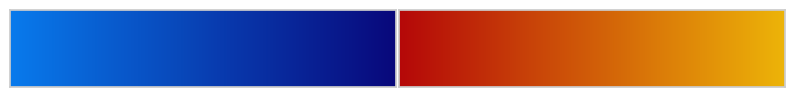

In [231]:
steps = 2000

fig, ax = plt.subplots(1,2, figsize=(10,1))
plt.subplots_adjust(wspace=0.01)

hex_colors = np.array(['b50808','bb1b08','c12e08','c84208','ce5408','d46708','db7b08','e18e08','e7a108','edb508'])#[::-1]
colors = [hex_to_rgb(hex_color) for hex_color in hex_colors]
gradient = generate_gradient_hsv(colors, steps)

fn = '/mnt/hdd2/associative_learning/paper_draft_v1/figures/gradient_valid_predomit.png'
ax[1].imshow([gradient], extent=[0, len(gradient), 0, 1], aspect='auto')
ax[1].set_xticks([])
ax[1].set_yticks([])

hex_colors = np.array(['087bed','086ee0','0861d3','0854c7','0848ba','083aae','082ea1','082194','081588','08087b'])
colors = [hex_to_rgb(hex_color) for hex_color in hex_colors]
gradient = generate_gradient_hsv(colors, steps)

ax[0].imshow([gradient], extent=[0, len(gradient), 0, 1], aspect='auto')
ax[0].set_xticks([])
ax[0].set_yticks([])

plt.savefig(fn, dpi=300)
plt.show()

---

# <center> $\Large\textbf{Congruent vs. Random}$ </center>

**Test the effect of prediction.**

In [188]:
regex1 = '_cong$'
regex2 = 'MANUAL'

set1 = {};set2 = {}
for layer_name, layer_id in zip(['Deep', 'Middle', 'Superficial'], ['L1', 'L2', 'L3']):
    tstats[layer_id] = []; pvals[layer_id] = []; df_set1 = {}; df_set2 = {}
    for region in regions:
        df_set1[region] = []
        df_set2[region] = []
        for subject in subjects:
            stimuli = tbx.utils.extract_stimuli(subject)
            betas_l = tbx.utils.extract_condition_betas(stimuli=stimuli,
                                                        betas=dataset[subject]['LH'][region]['betas_selected'][layer_id].values.T,
                                                        stimulus_type='sound')
            betas_r = tbx.utils.extract_condition_betas(stimuli=stimuli,
                                                        betas=dataset[subject]['RH'][region]['betas_selected'][layer_id].values.T,
                                                        stimulus_type='sound')
            
            df_set1[region].append(np.mean([
                np.nanmean(betas_l.filter(regex=regex1).values),
                np.nanmean(betas_r.filter(regex=regex1).values)]))
            df_set2[region].append(np.mean([
                np.nanmean(betas_l.filter(regex='^random').filter(regex='^(?!.*_omis$)').values),
                np.nanmean(betas_r.filter(regex='^random').filter(regex='^(?!.*_omis$)').values)]))
    set1[layer_id] = df_set1
    set2[layer_id] = df_set2

all_non_parametric_pvals = np.array([[non_parametric_permutation_ttest(np.subtract(set2[layer][region], set1[layer][region])) for layer in layers] for region in regions])
all_non_parametric_pvals_flat = np.array(all_non_parametric_pvals).ravel()
reject_fdr, p_adjusted = fdrcorrection(all_non_parametric_pvals_flat)
p_adjusted = p_adjusted.reshape(np.array(all_non_parametric_pvals).shape)


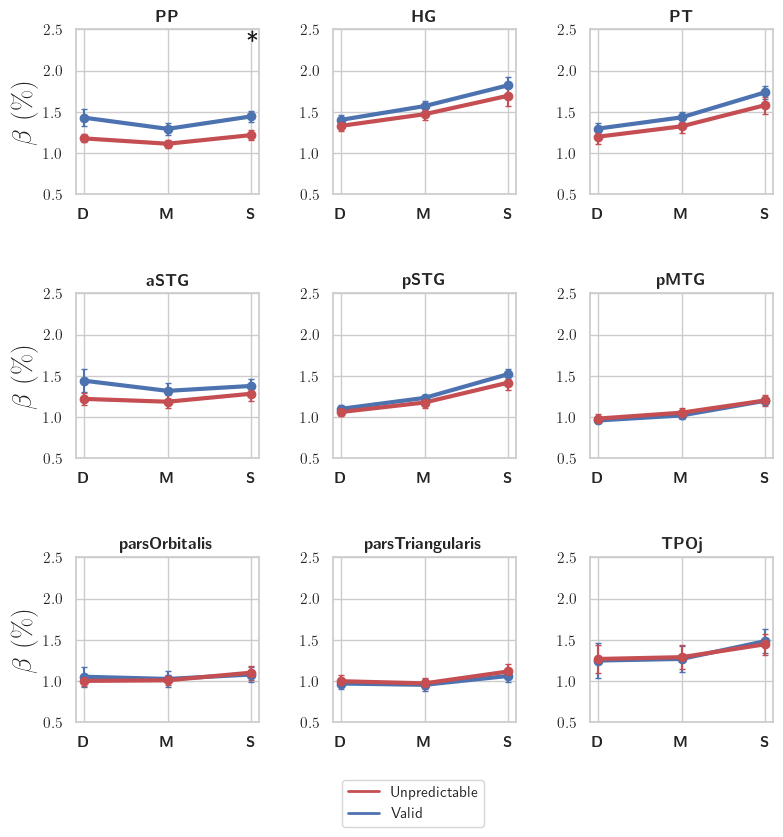

In [189]:

all_layer_pvals = []
for region in regions:
    for layerA, layerB in itertools.combinations(layers, 2):
        diff_betas_layerA = np.subtract(set2[layerA][region], set1[layerA][region]) # difference within layerA
        diff_betas_layerB = np.subtract(set2[layerB][region], set1[layerB][region]) # difference within layerB
        all_layer_pvals.append(non_parametric_permutation_ttest(diff_betas_layerA - diff_betas_layerB))


reject_fdr, p_layers_adjusted = fdrcorrection(all_layer_pvals)

all_non_parametric_pvals_for_layers = {}
idx = 0
for region in regions:
    all_non_parametric_pvals_for_layers[region] = {}
    for layerA, layerB in itertools.combinations(layers, 2):
        all_non_parametric_pvals_for_layers[region]['_'.join([layerA, layerB])] = p_layers_adjusted[idx]
        idx += 1


fig = plt.figure(figsize=(9, 9))
gs = gridspec.GridSpec(3, 3, height_ratios=[1, 1, 1], hspace=0.6, wspace=0.4)

ax1 = fig.add_subplot(gs[0, 0]) 
ax2 = fig.add_subplot(gs[0, 1]) 
ax3 = fig.add_subplot(gs[0, 2]) 
ax4 = fig.add_subplot(gs[1, 0]) 
ax5 = fig.add_subplot(gs[1, 1]) 
ax6 = fig.add_subplot(gs[1, 2]) 
ax7 = fig.add_subplot(gs[2, 0]) 
ax8 = fig.add_subplot(gs[2, 1]) 
ax9 = fig.add_subplot(gs[2, 2])

for idx, axis in enumerate(fig.get_axes()): # regions
    means1 = np.array([np.nanmean(set1[layer][regions[idx]]) for layer in layers])
    stderr1 = np.array([np.nanstd(set1[layer][regions[idx]]) for layer in layers])/np.sqrt(11)
    sns.lineplot(means1, ax=axis, c='b', linewidth=3)
    axis.errorbar(x=range(len(means1)), y=means1, yerr=stderr1, fmt='o', capsize=2, c='b')

    means2 = np.array([np.nanmean(set2[layer][regions[idx]]) for layer in layers])
    stderr2 = np.array([np.nanstd(set2[layer][regions[idx]]) for layer in layers])/np.sqrt(11)
    sns.lineplot(means2, ax=axis, c='r', linewidth=3)
    axis.errorbar(x=range(len(means2)), y=means2, yerr=stderr2, fmt='o', capsize=2, c='r')
                                     
    axis.set_xticks([0,1,2], [r'$\textbf{D}$', r'$\textbf{M}$', r'$\textbf{S}$'])
    axis.set_ylim([0.5, 2.5])
    if idx in [0,3,6]:
        axis.set_ylabel(r'$\mathbf{\beta\ (\%)}$', fontsize=20)
    axis.set_title(r'$\textbf{'+regions[idx]+r'}$')
    
    # make border thicker when there is an interaction
    # if regions[idx] in ['PP', 'HG', 'PT', 'aSTG', 'pSTG', 'parsOrbitalis', 'parsTriangularis', 'TPOj']:
    #     for spine in axis.spines.values():
    #         spine.set_linewidth(2)
    #         spine.set_color('black')
    # add layer interactions
    # if regions[idx] == 'PP':
    #     axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
    #     axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
    #     axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
    #     axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
    #     axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
    #     axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S


    if regions[idx] in ['PP']:
        axis.text(1.95, 2.35, '*', color='k', weight='bold', fontsize=20)

blue_line = mlines.Line2D([], [], color='b', linestyle='-', linewidth=2, label='Valid')
red_line = mlines.Line2D([], [], color='r', linestyle='-', linewidth=2, label='Unpredictable')
fig.legend(handles=[red_line, blue_line], loc='center', bbox_to_anchor=(.5, 0.02))

# Mean Activations of Congruent vs. Invalid Trials (11 Subjects, Averaged Hemisphere, Non-Parametric FDR Corrected
plt.savefig('./figures/univariate_laminar_cong_rand_nonparametric_fdr_friedman.png', dpi=300, bbox_inches='tight')
plt.show()

In [81]:
diffs = []
for idx, axis in enumerate(fig.get_axes()): # regions_selected
    means_diff = np.array([np.mean(np.array(set2[layer][regions_selected[idx]]) - np.array(set1[layer][regions_selected[idx]])) for layer in layers])
    stderr_diff = np.array([np.std(np.array(set2[layer][regions_selected[idx]]) - np.array(set1[layer][regions_selected[idx]])) for layer in layers])/np.sqrt(11)
    sns.lineplot(means_diff, ax=axis, c=palette[-2], linewidth=3)
    axis.errorbar(x=range(len(means_diff)), y=means_diff, yerr=stderr_diff, fmt='o', capsize=2, c=palette[-2])
    
    # friedman
    diffMeas = np.array([set2[item][regions_selected[idx]] for item in ['L1', 'L2', 'L3']]) - np.array([set1[item][regions_selected[idx]] for item in ['L1', 'L2', 'L3']]).astype(np.float64)
    
    print(np.mean(diffMeas, axis=1), '\t', regions_selected[idx])
    diffs.append(np.mean(diffMeas, axis=1))
diffs = np.array(diffs)

np.min(diffs), np.max(diffs)

[-0.25153667 -0.18038565 -0.22660938] 	 PP
[-0.07288932 -0.09833697 -0.12653546] 	 HG
[-0.09841448 -0.10887133 -0.15521832] 	 PT
[-0.22050787 -0.13170702 -0.09451621] 	 aSTG
[-0.03906584 -0.05574958 -0.10291654] 	 pSTG
[-0.05024938 -0.0165622   0.02227151] 	 parsOrbitalis
[0.02791659 0.01742755 0.05420866] 	 parsTriangularis
[ 0.01900358  0.02118803 -0.03723697] 	 TPOj


IndexError: list index out of range

---

# <center> $\Large\textbf{Omitted Predictable vs. Omitted Random}$ </center>

**Test the effect of prediction.**

In [190]:
regex1 = '^(?!random).*_omis$'
regex2 = '^random.*_omis$'

set1 = {};set2 = {}
for layer_name, layer_id in zip(['Deep', 'Middle', 'Superficial'], ['L1', 'L2', 'L3']):
    tstats[layer_id] = []; pvals[layer_id] = []; df_set1 = {}; df_set2 = {}
    for region in regions:
        df_set1[region] = []
        df_set2[region] = []
        for subject in subjects:
            stimuli = tbx.utils.extract_stimuli(subject)
            betas_l = tbx.utils.extract_condition_betas(stimuli=stimuli,
                                                        betas=dataset[subject]['LH'][region]['betas_selected'][layer_id].values.T,
                                                        stimulus_type='sound')
            betas_r = tbx.utils.extract_condition_betas(stimuli=stimuli,
                                                        betas=dataset[subject]['RH'][region]['betas_selected'][layer_id].values.T,
                                                        stimulus_type='sound')
            
            df_set1[region].append(np.mean([
                np.nanmean(betas_l.filter(regex=regex1).values),
                np.nanmean(betas_r.filter(regex=regex1).values)]))
            df_set2[region].append(np.mean([
                np.nanmean(betas_l.filter(regex=regex2).values),
                np.nanmean(betas_r.filter(regex=regex2).values)]))
    set1[layer_id] = df_set1
    set2[layer_id] = df_set2

all_non_parametric_pvals = np.array([[non_parametric_permutation_ttest(np.subtract(set2[layer][region], set1[layer][region])) for layer in layers] for region in regions])
all_non_parametric_pvals_flat = np.array(all_non_parametric_pvals).ravel()
reject_fdr, p_adjusted = fdrcorrection(all_non_parametric_pvals_flat)
p_adjusted = p_adjusted.reshape(np.array(all_non_parametric_pvals).shape)


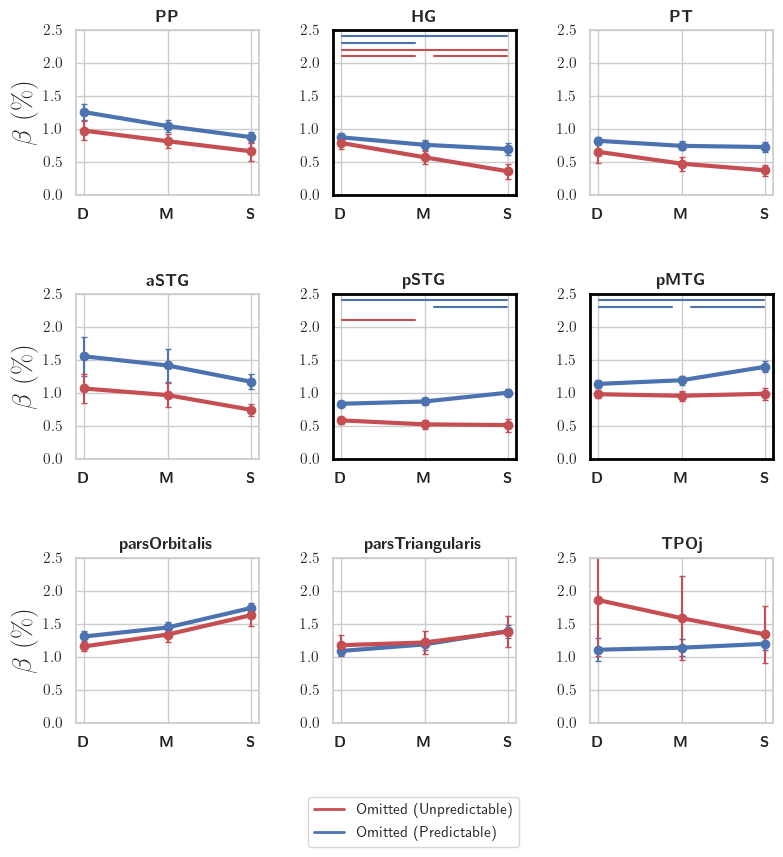

In [191]:

all_layer_pvals = []
for region in regions:
    for layerA, layerB in itertools.combinations(layers, 2):
        diff_betas_layerA = np.subtract(set2[layerA][region], set1[layerA][region]) # difference within layerA
        diff_betas_layerB = np.subtract(set2[layerB][region], set1[layerB][region]) # difference within layerB
        all_layer_pvals.append(non_parametric_permutation_ttest(diff_betas_layerA - diff_betas_layerB))


reject_fdr, p_layers_adjusted = fdrcorrection(all_layer_pvals)

all_non_parametric_pvals_for_layers = {}
idx = 0
for region in regions:
    all_non_parametric_pvals_for_layers[region] = {}
    for layerA, layerB in itertools.combinations(layers, 2):
        all_non_parametric_pvals_for_layers[region]['_'.join([layerA, layerB])] = p_layers_adjusted[idx]
        idx += 1


fig = plt.figure(figsize=(9, 9))
gs = gridspec.GridSpec(3, 3, height_ratios=[1, 1, 1], hspace=0.6, wspace=0.4)

ax1 = fig.add_subplot(gs[0, 0]) 
ax2 = fig.add_subplot(gs[0, 1]) 
ax3 = fig.add_subplot(gs[0, 2]) 
ax4 = fig.add_subplot(gs[1, 0]) 
ax5 = fig.add_subplot(gs[1, 1]) 
ax6 = fig.add_subplot(gs[1, 2]) 
ax7 = fig.add_subplot(gs[2, 0]) 
ax8 = fig.add_subplot(gs[2, 1]) 
ax9 = fig.add_subplot(gs[2, 2])

for idx, axis in enumerate(fig.get_axes()): # regions
    means1 = np.array([np.nanmean(set1[layer][regions[idx]]) for layer in layers])
    stderr1 = np.array([np.nanstd(set1[layer][regions[idx]]) for layer in layers])/np.sqrt(11)
    sns.lineplot(means1, ax=axis, c='b', linewidth=3)
    axis.errorbar(x=range(len(means1)), y=means1, yerr=stderr1, fmt='o', capsize=2, c='b')

    means2 = np.array([np.nanmean(set2[layer][regions[idx]]) for layer in layers])
    stderr2 = np.array([np.nanstd(set2[layer][regions[idx]]) for layer in layers])/np.sqrt(11)
    sns.lineplot(means2, ax=axis, c='r', linewidth=3)
    axis.errorbar(x=range(len(means2)), y=means2, yerr=stderr2, fmt='o', capsize=2, c='r')
                                     
    axis.set_xticks([0,1,2], [r'$\textbf{D}$', r'$\textbf{M}$', r'$\textbf{S}$'])
    axis.set_ylim([0., 2.5])
    if idx in [0,3,6]:
        axis.set_ylabel(r'$\mathbf{\beta\ (\%)}$', fontsize=20)
    axis.set_title(r'$\textbf{'+regions[idx]+r'}$')
    
    # make border thicker when there is an interaction
    if regions[idx] in ['HG', 'pSTG', 'pMTG']:
        for spine in axis.spines.values():
            spine.set_linewidth(2)
            spine.set_color('black')
    # add layer interactions
    if regions[idx] == 'HG':
        axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
        axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
        # axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
        axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
        axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
        axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S
    if regions[idx] == 'pSTG':
        axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
        # axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
        axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
        # axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
        axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
        # axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S
    if regions[idx] == 'pMTG':
        axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
        axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
        axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
        # axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
        # axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
        # axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S


blue_line = mlines.Line2D([], [], color='b', linestyle='-', linewidth=2, label='Omitted (Predictable)')
red_line = mlines.Line2D([], [], color='r', linestyle='-', linewidth=2, label='Omitted (Unpredictable)')
fig.legend(handles=[red_line, blue_line], loc='center', bbox_to_anchor=(.5, 0.))
    
# Mean Activations of Congruent vs. Invalid Trials (11 Subjects, Averaged Hemisphere, Non-Parametric FDR Corrected
# plt.savefig('./results/univariate_laminar_congomit_randomit_nonparametric_fdr.png', dpi=300, bbox_inches='tight')
plt.savefig('./figures/univariate_laminar_congomis_randomis_nonparametric_fdr_friedman.png', dpi=300, bbox_inches='tight')
plt.show()

FriedmanchisquareResult(statistic=8.909090909090907, pvalue=0.011625603038838514)
Note: Intervals can be used for testing but are not simultaneous confidence intervals.
\begin{tabular}{lrrrr}
\toprule
 & Lower CI & Mean rank Diff & Upper CI & p-value \\
\midrule
D-M & -0.362994 & 0.636364 & 1.635721 & 0.294540 \\
D-S & 0.273370 & 1.272727 & 2.272085 & 0.007987 \\
M-S & -0.362994 & 0.636364 & 1.635721 & 0.294540 \\
\bottomrule
\end{tabular}

FriedmanchisquareResult(statistic=16.54545454545456, pvalue=0.00025538782834452984)
Note: Intervals can be used for testing but are not simultaneous confidence intervals.
\begin{tabular}{lrrrr}
\toprule
 & Lower CI & Mean rank Diff & Upper CI & p-value \\
\midrule
D-M & 0.000643 & 1.000000 & 1.999357 & 0.049810 \\
D-S & 0.727915 & 1.727273 & 2.726630 & 0.000151 \\
M-S & -0.272085 & 0.727273 & 1.726630 & 0.203037 \\
\bottomrule
\end{tabular}

FriedmanchisquareResult(statistic=10.363636363636374, pvalue=0.005617782972323385)
Note: Intervals can be use

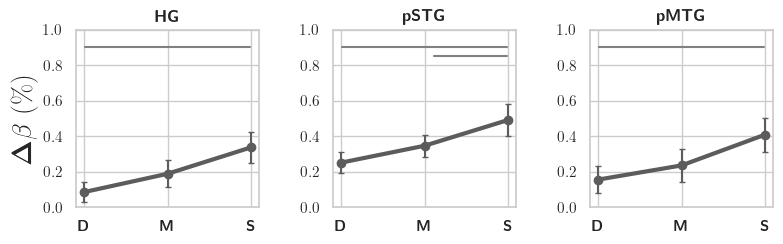

In [192]:
regions_selected = ['HG', 'pSTG', 'pMTG']
palette = sns.color_palette('Grays')

all_layer_pvals = []
for region in regions_selected:
    for layerA, layerB in itertools.combinations(layers, 2):
        diff_betas_layerA = np.subtract(set2[layerA][region], set1[layerA][region]) # difference within layerA
        diff_betas_layerB = np.subtract(set2[layerB][region], set1[layerB][region]) # difference within layerB
        all_layer_pvals.append(non_parametric_permutation_ttest(diff_betas_layerA - diff_betas_layerB))


reject_fdr, p_layers_adjusted = fdrcorrection(all_layer_pvals)

all_non_parametric_pvals_for_layers = {}
idx = 0
for region in regions_selected:
    all_non_parametric_pvals_for_layers[region] = {}
    for layerA, layerB in itertools.combinations(layers, 2):
        all_non_parametric_pvals_for_layers[region]['_'.join([layerA, layerB])] = p_layers_adjusted[idx]
        idx += 1


fig = plt.figure(figsize=(9, 6))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], hspace=0.6, wspace=0.4)

ax1 = fig.add_subplot(gs[0, 0]) 
ax2 = fig.add_subplot(gs[0, 1]) 
ax3 = fig.add_subplot(gs[0, 2]) 

for idx, axis in enumerate(fig.get_axes()): # regions_selected
    # means_diff = np.array([np.nanmean(np.array(set2[layer][regions_selected[idx]]) - np.array(set1[layer][regions_selected[idx]])) for layer in layers])
    # stderr_diff = np.array([np.nanstd(np.array(set2[layer][regions_selected[idx]]) - np.array(set1[layer][regions_selected[idx]])) for layer in layers])/np.sqrt(11)
    means_diff = np.array([np.nanmean(np.array(set1[layer][regions_selected[idx]]) - np.array(set2[layer][regions_selected[idx]])) for layer in layers])
    stderr_diff = np.array([np.nanstd(np.array(set1[layer][regions_selected[idx]]) - np.array(set2[layer][regions_selected[idx]])) for layer in layers])/np.sqrt(11)
    
    sns.lineplot(means_diff, ax=axis, c=palette[-2], linewidth=3)
    axis.errorbar(x=range(len(means_diff)), y=means_diff, yerr=stderr_diff, fmt='o', capsize=2, c=palette[-2])
    
    friedman
    diffMeas = np.array([set2[item][regions_selected[idx]] for item in ['L1', 'L2', 'L3']]) - np.array([set1[item][regions_selected[idx]] for item in ['L1', 'L2', 'L3']])
    friedman = friedmanchisquare(*diffMeas)
    print(friedman)
    # apply multcompare
    eng = matlab.engine.start_matlab()
    diffMeas_ml = matlab.double(diffMeas.tolist())
    eng.workspace['diffMeas'] = diffMeas_ml
    eng.eval("[p,tbl,stats] = friedman(diffMeas',1);", nargout=0)
    c = eng.eval("multcompare(stats);", nargout=1)
    c_py = np.array(c)
    eng.quit()
    print(pd.DataFrame(c_py[:,2:], index=['D-M', 'D-S', 'M-S'], columns=['Lower CI', 'Mean rank Diff', 'Upper CI', 'p-value']).to_latex())

    if regions_selected[idx] == 'HG':
        axis.axhline(0.9, 0.05, 0.95, c='gray', linewidth=1.5) # D-S
        # axis.axhline(2.3-2.3+0.2, 0.05, 0.45, c='gray', linewidth=1.5) # D-M
        # axis.axhline(2.3-2.3+0.2, 0.55, 0.95, c='gray', linewidth=1.5) # M-S
    if regions_selected[idx] == 'pSTG':
        axis.axhline(0.9, 0.05, 0.95, c='gray', linewidth=1.5) # D-S
        # axis.axhline(2.3-2.3+0.2, 0.05, 0.45, c='gray', linewidth=1.5) # D-M
        axis.axhline(0.85, 0.55, 0.95, c='gray', linewidth=1.5) # M-S
    if regions_selected[idx] == 'pMTG':
        axis.axhline(0.9, 0.05, 0.95, c='gray', linewidth=1.5) # D-S
        # axis.axhline(2.3-2.3+0.2, 0.05, 0.45, c='gray', linewidth=1.5) # D-M
        # axis.axhline(2.3-2.3+0.2, 0.55, 0.95, c='gray', linewidth=1.5) # M-S
    
    axis.set_xticks([0,1,2], [r'$\textbf{D}$', r'$\textbf{M}$', r'$\textbf{S}$'])
    axis.set_ylim([0.0, 1.0])
    if idx in [0,4]:
        axis.set_ylabel(r'$\mathbf{\Delta\beta\ (\%)}$', fontsize=20)
    axis.set_title(r'$\textbf{'+regions_selected[idx]+r'}$')

# blue_line = mlines.Line2D([], [], color='b', linestyle='-', linewidth=2, label='Valid')
# red_line = mlines.Line2D([], [], color='r', linestyle='-', linewidth=2, label='Invalid')
# fig.legend(handles=[red_line, blue_line], loc='center', bbox_to_anchor=(.5, 0.02))

# Mean Activations of Congruent vs. Invalid Trials (11 Subjects, Averaged Hemisphere, Non-Parametric FDR Corrected
plt.savefig('./figures/univariate_laminar_congomis_randomis_nonparametric_fdr_friedman_posthoc.png', dpi=300, bbox_inches='tight')
plt.show()

In [198]:
diffs = []
for idx, axis in enumerate(fig.get_axes()): # regions_selected
    means_diff = np.array([np.mean(np.array(set2[layer][regions_selected[idx]]) - np.array(set1[layer][regions_selected[idx]])) for layer in layers])
    stderr_diff = np.array([np.std(np.array(set2[layer][regions_selected[idx]]) - np.array(set1[layer][regions_selected[idx]])) for layer in layers])/np.sqrt(11)
    sns.lineplot(means_diff, ax=axis, c=palette[-2], linewidth=3)
    axis.errorbar(x=range(len(means_diff)), y=means_diff, yerr=stderr_diff, fmt='o', capsize=2, c=palette[-2])
    
    # friedman
    diffMeas = np.array([set2[item][regions_selected[idx]] for item in ['L1', 'L2', 'L3']]) - np.array([set1[item][regions_selected[idx]] for item in ['L1', 'L2', 'L3']]).astype(np.float64)
    
    print(np.mean(diffMeas, axis=1), '\t', regions_selected[idx])
    diffs.append(np.mean(diffMeas, axis=1))
diffs = np.array(diffs) * -1

np.min(diffs), np.max(diffs)

[-0.08562373 -0.18858139 -0.33709003] 	 HG
[-0.25127782 -0.34631319 -0.49109694] 	 pSTG
[-0.15572047 -0.23561127 -0.40848673] 	 pMTG


(0.08562372760339217, 0.49109694124622777)

In [195]:
mincol, maxcol

(0.1, 0.4)

In [199]:
all_regs = [entry['Name'] for entry in smp_head['Map']]

indcs = np.array([0,4,5])

selected = ['HG', 'pSTG', 'pMTG']

# Superficial
# _, indcs, _ = np.intersect1d(all_regs, selected, return_indices=True)
smp_head_cp = deepcopy(smp_head)
smp_head_cp['Nr maps'] = len(indcs)
smp_head_cp['Map'] = list(np.array(smp_head_cp['Map'])[indcs])
data = deepcopy(smp_data[:, indcs])

for idx, tval in enumerate(diffs[:,0]):
    data[:, idx][data[:, idx]==6] = tval
    smp_head_cp['Map'][idx]['Threshold min'] = mincol
    smp_head_cp['Map'][idx]['Threshold max'] = maxcol
print(smp_head_cp['Map'][idx]['Threshold min'], smp_head_cp['Map'][idx]['Threshold max'])
bvbabel.smp.write_smp('/mnt/hdd2/associative_learning/paper_draft_v1/figures/group_patches_LH_univariate_predomit_unpredomit_dep.smp', smp_head_cp, data)

# Middle
# _, indcs, _ = np.intersect1d(all_regs, selected, return_indices=True)
smp_head_cp = deepcopy(smp_head)
smp_head_cp['Nr maps'] = len(indcs)
smp_head_cp['Map'] = list(np.array(smp_head_cp['Map'])[indcs])
data = deepcopy(smp_data[:, indcs])

for idx, tval in enumerate(diffs[:,1]):
    data[:, idx][data[:, idx]==6] = tval
    smp_head_cp['Map'][idx]['Threshold min'] = mincol
    smp_head_cp['Map'][idx]['Threshold max'] = maxcol
print(smp_head_cp['Map'][idx]['Threshold min'], smp_head_cp['Map'][idx]['Threshold max'])
bvbabel.smp.write_smp('/mnt/hdd2/associative_learning/paper_draft_v1/figures/group_patches_LH_univariate_predomit_unpredomit_mid.smp', smp_head_cp, data)

# Deep
# _, indcs, _ = np.intersect1d(all_regs, selected, return_indices=True)
smp_head_cp = deepcopy(smp_head)
smp_head_cp['Nr maps'] = len(indcs)
smp_head_cp['Map'] = list(np.array(smp_head_cp['Map'])[indcs])
data = deepcopy(smp_data[:, indcs])

for idx, tval in enumerate(diffs[:,2]):
    data[:, idx][data[:, idx]==6] = tval
    smp_head_cp['Map'][idx]['Threshold min'] = mincol
    smp_head_cp['Map'][idx]['Threshold max'] = maxcol
print(smp_head_cp['Map'][idx]['Threshold min'], smp_head_cp['Map'][idx]['Threshold max'])
bvbabel.smp.write_smp('/mnt/hdd2/associative_learning/paper_draft_v1/figures/group_patches_LH_univariate_predomit_unpredomit_sup.smp', smp_head_cp, data)


0.1 0.4
0.1 0.4
0.1 0.4


---

# <center> $\Large\textbf{Unpredictable vs. Omitted (Unpredictable)}$ </center>

**Test the effect of prediction.**

In [29]:
regex1 = 'MANUAL' #'^random.*_(?!omis)$'
regex2 = '^random.*_omis$'

set1 = {};set2 = {}
for layer_name, layer_id in zip(['Deep', 'Middle', 'Superficial'], ['L1', 'L2', 'L3']):
    tstats[layer_id] = []; pvals[layer_id] = []; df_set1 = {}; df_set2 = {}
    for region in regions:
        df_set1[region] = []
        df_set2[region] = []
        for subject in subjects:
            stimuli = tbx.utils.extract_stimuli(subject)
            betas_l = tbx.utils.extract_condition_betas(stimuli=stimuli,
                                                        betas=dataset[subject]['LH'][region]['betas_selected'][layer_id].values.T,
                                                        stimulus_type='sound')
            betas_r = tbx.utils.extract_condition_betas(stimuli=stimuli,
                                                        betas=dataset[subject]['RH'][region]['betas_selected'][layer_id].values.T,
                                                        stimulus_type='sound')
            
            df_set1[region].append(np.mean([
                np.nanmean(betas_l.filter(regex='^random').filter(regex='^(?!.*_omis$)').values),
                np.nanmean(betas_r.filter(regex='^random').filter(regex='^(?!.*_omis$)').values)]))
            df_set2[region].append(np.mean([
                np.nanmean(betas_l.filter(regex=regex2).values),
                np.nanmean(betas_r.filter(regex=regex2).values)]))
    set1[layer_id] = df_set1
    set2[layer_id] = df_set2

all_non_parametric_pvals = np.array([[non_parametric_permutation_ttest(np.subtract(set2[layer][region], set1[layer][region])) for layer in layers] for region in regions])
all_non_parametric_pvals_flat = np.array(all_non_parametric_pvals).ravel()
reject_fdr, p_adjusted = fdrcorrection(all_non_parametric_pvals_flat)
p_adjusted = p_adjusted.reshape(np.array(all_non_parametric_pvals).shape)


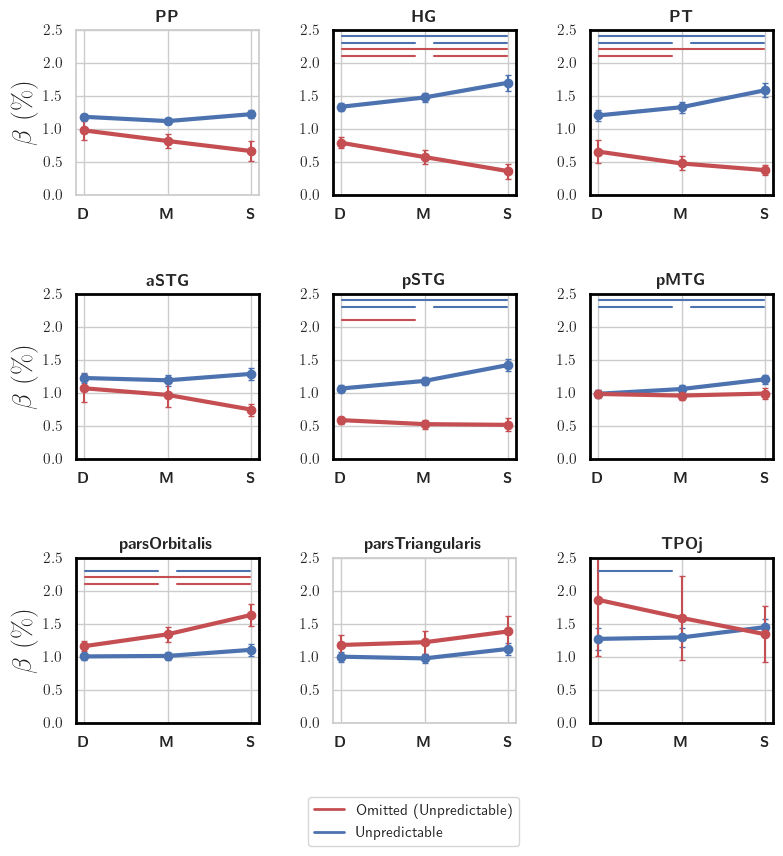

In [44]:

all_layer_pvals = []
for region in regions:
    for layerA, layerB in itertools.combinations(layers, 2):
        diff_betas_layerA = np.subtract(set2[layerA][region], set1[layerA][region]) # difference within layerA
        diff_betas_layerB = np.subtract(set2[layerB][region], set1[layerB][region]) # difference within layerB
        all_layer_pvals.append(non_parametric_permutation_ttest(diff_betas_layerA - diff_betas_layerB))


reject_fdr, p_layers_adjusted = fdrcorrection(all_layer_pvals)

all_non_parametric_pvals_for_layers = {}
idx = 0
for region in regions:
    all_non_parametric_pvals_for_layers[region] = {}
    for layerA, layerB in itertools.combinations(layers, 2):
        all_non_parametric_pvals_for_layers[region]['_'.join([layerA, layerB])] = p_layers_adjusted[idx]
        idx += 1


fig = plt.figure(figsize=(9, 9))
gs = gridspec.GridSpec(3, 3, height_ratios=[1, 1, 1], hspace=0.6, wspace=0.4)

ax1 = fig.add_subplot(gs[0, 0]) 
ax2 = fig.add_subplot(gs[0, 1]) 
ax3 = fig.add_subplot(gs[0, 2]) 
ax4 = fig.add_subplot(gs[1, 0]) 
ax5 = fig.add_subplot(gs[1, 1]) 
ax6 = fig.add_subplot(gs[1, 2]) 
ax7 = fig.add_subplot(gs[2, 0]) 
ax8 = fig.add_subplot(gs[2, 1]) 
ax9 = fig.add_subplot(gs[2, 2])

for idx, axis in enumerate(fig.get_axes()): # regions
    means1 = np.array([np.nanmean(set1[layer][regions[idx]]) for layer in layers])
    stderr1 = np.array([np.nanstd(set1[layer][regions[idx]]) for layer in layers])/np.sqrt(11)
    sns.lineplot(means1, ax=axis, c='b', linewidth=3)
    axis.errorbar(x=range(len(means1)), y=means1, yerr=stderr1, fmt='o', capsize=2, c='b')

    means2 = np.array([np.nanmean(set2[layer][regions[idx]]) for layer in layers])
    stderr2 = np.array([np.nanstd(set2[layer][regions[idx]]) for layer in layers])/np.sqrt(11)
    sns.lineplot(means2, ax=axis, c='r', linewidth=3)
    axis.errorbar(x=range(len(means2)), y=means2, yerr=stderr2, fmt='o', capsize=2, c='r')
                                     
    axis.set_xticks([0,1,2], [r'$\textbf{D}$', r'$\textbf{M}$', r'$\textbf{S}$'])
    axis.set_ylim([0., 2.5])
    if idx in [0,3,6]:
        axis.set_ylabel(r'$\mathbf{\beta\ (\%)}$', fontsize=20)
    axis.set_title(r'$\textbf{'+regions[idx]+r'}$')
    
    # make border thicker when there is an interaction
    if regions[idx] in ['PT', 'HG', 'aSTG', 'pSTG', 'pMTG', 'parsOrbitalis', 'TPOj']:
        for spine in axis.spines.values():
            spine.set_linewidth(2)
            spine.set_color('black')
    # add layer interactions
    if regions[idx] == 'HG':
        axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
        axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
        axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
        axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
        axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
        axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S
    if regions[idx] == 'PT':
        axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
        axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
        axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
        axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
        axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
        # axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S
    # if regions[idx] == 'aSTG':
    #     axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
    #     axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
    #     axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
    #     axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
    #     axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
    #     axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S
    if regions[idx] == 'pSTG':
        axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
        axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
        axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
        # axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
        axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
        # axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S
    if regions[idx] == 'pMTG':
        axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
        axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
        axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
        # axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
        # axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
        # axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S
    if regions[idx] == 'parsOrbitalis':
        # axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
        axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
        axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
        axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
        axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
        axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S
    if regions[idx] == 'TPOj':
        # axis.axhline(2.4, 0.05, 0.95, c='b', linewidth=1.5) # D-S
        axis.axhline(2.3, 0.05, 0.45, c='b', linewidth=1.5) # D-M
        # axis.axhline(2.3, 0.55, 0.95, c='b', linewidth=1.5) # M-S
        # axis.axhline(2.2, 0.05, 0.95, c='r', linewidth=1.5) # D-S
        # axis.axhline(2.1, 0.05, 0.45, c='r', linewidth=1.5) # D-M
        # axis.axhline(2.1, 0.55, 0.95, c='r', linewidth=1.5) # M-S


blue_line = mlines.Line2D([], [], color='b', linestyle='-', linewidth=2, label='Unpredictable')
red_line = mlines.Line2D([], [], color='r', linestyle='-', linewidth=2, label='Omitted (Unpredictable)')
fig.legend(handles=[red_line, blue_line], loc='center', bbox_to_anchor=(.5, 0.))
    
# Mean Activations of Congruent vs. Invalid Trials (11 Subjects, Averaged Hemisphere, Non-Parametric FDR Corrected
# plt.savefig('./results/univariate_laminar_congomit_randomit_nonparametric_fdr.png', dpi=300, bbox_inches='tight')
plt.savefig('./figures/univariate_laminar_rand_randomis_nonparametric_fdr_friedman.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
# friedman

pvals = []
stats = []
for roi in regions:
    cong = np.array([set1[item][roi] for item in ['L1', 'L2', 'L3']])
    incong = np.array([set2[item][roi] for item in ['L1', 'L2', 'L3']])
    statistic, pvalue = friedmanchisquare(*(incong-cong))
    pvals.append(pvalue)
    stats.append(statistic)
    # print(f'{roi:<16}: statistic={statistic:0.8f}, \t pvalue={pvalue:0.8f}', end='\t')
    # if pvalue < 0.05:
    #     print('*')
    # else:
    #     print()


data = [{'ROI':roi, 'stat':f'{stats[idx]:0.8f}', 'p':f'{pvals[idx]:0.8f}'} for idx, roi in enumerate(regions)]

headers = data[0].keys()

latex_table_uncorrected = (
    # "\\begin{table}[h!]\n"
    # "\\centering\n"
    "\\caption{Friedman}\n"
    "\\begin{tabular}{" + " ".join(["l"] * len(headers)) + "}\n"
    "\\toprule\n"
)
latex_table_uncorrected += " & ".join(headers) + " \\\\\n\\midrule\n"

for row in data:
    # if float(row['p']) < 0.05:
    #     latex_table_uncorrected += " & ".join('\\textbf{'+str(row[h])+'}' for h in headers) + " \\\\\n"
    # else:
    latex_table_uncorrected += " & ".join(str(row[h]) for h in headers) + " \\\\\n"

latex_table_uncorrected += (
    "\\bottomrule\n"
    "\\end{tabular}\n"
    # "\\end{table}"
)

#%%%%%%%%%%%%%

rejections, pvals_corrected = fdrcorrection(pvals)

for idx, roi in enumerate(regions):
    statistic = stats[idx]
    pvalue = pvals_corrected[idx]
    # print(f'{roi:<16}: statistic={statistic:0.8f}, \t pvalue={pvalue:0.8f}', end='\t')
    # if pvalue < 0.05:
    #     print('*')
    # else:
    #     print()

data = [{'ROI':roi, 'stat':f'{stats[idx]:0.8f}', 'p':f'{pvals_corrected[idx]:0.8f}'} for idx, roi in enumerate(regions)]

headers = data[0].keys()

latex_table = (
    # "\\begin{table}[h!]\n"
    # "\\centering\n"
    "\\caption{Friedman (FDR)}\n"
    "\\begin{tabular}{" + " ".join(["l"] * len(headers)) + "}\n"
    "\\toprule\n"
)
latex_table += " & ".join(headers) + " \\\\\n\\midrule\n"

for row in data:
    # if float(row['p']) < 0.05:
    #     latex_table += " & ".join('\\textbf{'+str(row[h])+'}' for h in headers) + " \\\\\n"
    # else:
    latex_table += " & ".join(str(row[h]) for h in headers) + " \\\\\n"

latex_table += (
    "\\bottomrule\n"
    "\\end{tabular}\n"
    # "\\end{table}"
)


print('''\\begin{table}[htbp]
    \\centering''')

print('\\begin{minipage}{0.45\\textwidth}')
print(latex_table_uncorrected)
print('\\end{minipage}')


print('\\hfill\\begin{minipage}{0.45\\textwidth}')
print(latex_table)
print('\\end{minipage}')

print('\\end{table}')
print()



\begin{table}[htbp]
    \centering
\begin{minipage}{0.45\textwidth}
\caption{Friedman}
\begin{tabular}{l l l}
\toprule
ROI & stat & p \\
\midrule
PP & 4.90909091 & 0.08590223 \\
HG & 20.18181818 & 0.00004145 \\
PT & 22.00000000 & 0.00001670 \\
aSTG & 6.72727273 & 0.03460918 \\
pSTG & 22.00000000 & 0.00001670 \\
pMTG & 6.54545455 & 0.03790291 \\
parsOrbitalis & 13.27272727 & 0.00131179 \\
parsTriangularis & 1.27272727 & 0.52921334 \\
TPOj & 7.09090909 & 0.02885550 \\
\bottomrule
\end{tabular}

\end{minipage}
\hfill\begin{minipage}{0.45\textwidth}
\caption{Friedman (FDR)}
\begin{tabular}{l l l}
\toprule
ROI & stat & p \\
\midrule
PP & 4.90909091 & 0.09664001 \\
HG & 20.18181818 & 0.00012436 \\
PT & 22.00000000 & 0.00007516 \\
aSTG & 6.72727273 & 0.04873232 \\
pSTG & 22.00000000 & 0.00007516 \\
pMTG & 6.54545455 & 0.04873232 \\
parsOrbitalis & 13.27272727 & 0.00295152 \\
parsTriangularis & 1.27272727 & 0.52921334 \\
TPOj & 7.09090909 & 0.04873232 \\
\bottomrule
\end{tabular}

\end{minipag

In [37]:
# interactions

inter = ['PT', 'HG', 'aSTG', 'pSTG', 'pMTG', 'parsOrbitalis', 'TPOj']

# anova
all_results = []
for roi in inter:
    cong = np.array([set1[item][roi] for item in ['L1', 'L2', 'L3']])
    incong = np.array([set2[item][roi] for item in ['L1', 'L2', 'L3']])
    
    result = {
        'D-M (cong)': non_parametric_permutation_ttest(cong[0,:]-cong[1,:]),
        'D-S (cong)': non_parametric_permutation_ttest(cong[0,:]-cong[2,:]),
        'M-S (cong)': non_parametric_permutation_ttest(cong[1,:]-cong[2,:]),
        'D-M (incong)': non_parametric_permutation_ttest(incong[0,:]-incong[1,:]),
        'D-S (incong)': non_parametric_permutation_ttest(incong[0,:]-incong[2,:]),
        'M-S (incong)': non_parametric_permutation_ttest(incong[1,:]-incong[2,:])
    }
    all_results.append(list(result.values()))
    
# correct and print
rej, pcorr = fdrcorrection(np.array(all_results).ravel())
pcorr = pcorr.reshape(len(inter), 6)
for idx, roi in enumerate(inter):
    cong = np.array([set1[item][roi] for item in ['L1', 'L2', 'L3']])
    incong = np.array([set2[item][roi] for item in ['L1', 'L2', 'L3']])
    
    result = {
        'D-M (cong)': non_parametric_permutation_ttest(cong[0,:]-cong[1,:]),
        'D-S (cong)': non_parametric_permutation_ttest(cong[0,:]-cong[2,:]),
        'M-S (cong)': non_parametric_permutation_ttest(cong[1,:]-cong[2,:]),
        'D-M (incong)': non_parametric_permutation_ttest(incong[0,:]-incong[1,:]),
        'D-S (incong)': non_parametric_permutation_ttest(incong[0,:]-incong[2,:]),
        'M-S (incong)': non_parametric_permutation_ttest(incong[1,:]-incong[2,:])
    }
    
    stats = {
        'D-M (cong)': np.round(ttest_rel(cong[0,:],cong[1,:]).statistic, 6),
        'D-S (cong)': np.round(ttest_rel(cong[0,:],cong[2,:]).statistic, 6),
        'M-S (cong)': np.round(ttest_rel(cong[1,:],cong[2,:]).statistic, 6),
        'D-M (incong)': np.round(ttest_rel(incong[0,:],incong[1,:]).statistic, 6),
        'D-S (incong)': np.round(ttest_rel(incong[0,:],incong[2,:]).statistic, 6),
        'M-S (incong)': np.round(ttest_rel(incong[1,:],incong[2,:]).statistic, 6)
    }

    print('''\\begin{table}[htbp]
        \\centering
        \\caption{Layer Effects for separate conditions (\\textbf{''' + roi + '''})}
        \\label{tab:my_label}''')

    print('\\begin{minipage}{0.45\\textwidth}')
    print('\\caption{Uncorrected}')
    print(pd.DataFrame([list(stats.values()), list(result.values())], columns=result.keys(),index=['t', 'p']).T.to_latex(index=True))
    print('\\end{minipage}')

    print('\\begin{minipage}{0.45\\textwidth}')
    print('\\caption{FDR}')
    print(pd.DataFrame([list(stats.values()), pcorr[idx]], columns=result.keys(), index=['t', 'q']).T.to_latex(index=True))
    print('\\end{minipage}')
    print('\\end{table}')
    print()

\begin{table}[htbp]
        \centering
        \caption{Layer Effects for separate conditions (\textbf{PT})}
        \label{tab:my_label}
\begin{minipage}{0.45\textwidth}
\caption{Uncorrected}
\begin{tabular}{lrr}
\toprule
 & t & p \\
\midrule
D-M (cong) & -4.464251 & 0.000488 \\
D-S (cong) & -5.680459 & 0.000488 \\
M-S (cong) & -4.642866 & 0.001465 \\
D-M (incong) & 2.011272 & 0.010254 \\
D-S (incong) & 1.928712 & 0.015137 \\
M-S (incong) & 1.573583 & 0.139160 \\
\bottomrule
\end{tabular}

\end{minipage}
\begin{minipage}{0.45\textwidth}
\caption{FDR}
\begin{tabular}{lrr}
\toprule
 & t & q \\
\midrule
D-M (cong) & -4.464251 & 0.002563 \\
D-S (cong) & -5.680459 & 0.002563 \\
M-S (cong) & -4.642866 & 0.003619 \\
D-M (incong) & 2.011272 & 0.020508 \\
D-S (incong) & 1.928712 & 0.028897 \\
M-S (incong) & 1.573583 & 0.208740 \\
\bottomrule
\end{tabular}

\end{minipage}
\end{table}

\begin{table}[htbp]
        \centering
        \caption{Layer Effects for separate conditions (\textbf{HG})}
  

---